# Ammonia decomposition ML — paper-style, score-optimized Kaggle notebook

This notebook applies the strongest useful parts of the referenced study to the supplied ammonia-decomposition workbook: broad nonlinear learners, chemistry/process descriptors, controlled curve interpolation, and hyperparameter/ensemble selection. The primary NH₃-conversion result is a **shuffled 10-fold out-of-fold R²**, matching the paper's interpolation-style validation.

To keep the result honest, model weights are selected **inside each outer training fold**. The outer validation rows are never used to tune that fold. A second, clearly separated publication-disjoint holdout estimates the harder unseen-literature performance.

The score cannot be guaranteed before Kaggle executes the notebook, but the workflow is explicitly optimized for the highest reproducible R² without target leakage. It also retains the high-H₂ classification task.


## Kaggle instructions

1. Import this `.ipynb` into Kaggle.
2. Use **Add Input** to attach `63bedc36-5c81-4d21-8291-23b426d3c95e.xlsx` (renaming is fine).
3. Select **CPU** and enable Internet only if Kaggle needs to install a missing package.
4. Run all cells from top to bottom.
5. Download the ZIP produced by the last cell.

The main R² is a paper-comparable within-dataset interpolation score. It must not be described as unseen-publication performance; the notebook prints that stricter score separately.


In [1]:
import importlib.util
import subprocess
import sys

REQUIRED = {
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "catboost": "catboost",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "joblib": "joblib",
    "shap": "shap",
}
missing = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are installed.")


All required packages are installed.


In [2]:
from pathlib import Path

DATA_PATH_OVERRIDE = None

if DATA_PATH_OVERRIDE is not None:
    selected = Path(DATA_PATH_OVERRIDE)
    if not selected.exists():
        raise FileNotFoundError(selected)
    DATA_PATH = str(selected)
else:
    roots = [p for p in [Path("/kaggle/input"), Path.cwd()] if p.exists()]
    excel_files = []
    seen = set()
    for root in roots:
        for p in root.rglob("*.xlsx"):
            if p.name.startswith("~$"):
                continue
            resolved = str(p.resolve())
            if resolved not in seen:
                seen.add(resolved)
                excel_files.append(p)
    likely = [p for p in excel_files if "ammon" in str(p).lower() or "amonia" in str(p).lower()]
    candidates = likely or excel_files
    if len(candidates) != 1:
        print("Excel candidates:")
        for p in candidates:
            print(" -", p)
        raise FileNotFoundError("Set DATA_PATH_OVERRIDE because the dataset was not uniquely resolved.")
    DATA_PATH = str(candidates[0])

print("Dataset:", DATA_PATH)


Dataset: /kaggle/input/datasets/digantadasdroba/amonia-decomposition-processed/Amonia Decomposition_Processed.xlsx


In [3]:
from pathlib import Path

SHEET_NAME = 0
RANDOM_SEED = 42
ROW_CV_FOLDS = 10
TARGET_R2 = 0.60

# Score-oriented, leakage-safe options.
TUNE_ENSEMBLE_INSIDE_EACH_FOLD = True
INNER_VALID_FRACTION = 0.20
BLEND_GRID_STEP = 0.10
RUN_AUGMENTATION_AUDIT = True
AUTO_USE_AUGMENTATION = True
AUGMENTATION_MIN_R2_GAIN = 0.002
RUN_STRICT_PUBLICATION_AUDIT = True

STRICT_H2_UNIT_POLICY = True
GOOD_H2_QUANTILE = 0.50

DEFAULT_BLEND_WEIGHTS = {"lightgbm": 0.40, "xgboost": 0.35, "catboost": 0.25}

if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working/Ammonia_Paper_Approach_Best_R2")
else:
    OUTPUT_DIR = Path.cwd() / "Ammonia_Paper_Approach_Best_R2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output:", OUTPUT_DIR)
print("Primary protocol: shuffled", ROW_CV_FOLDS, "fold out-of-fold prediction")
print("Nested ensemble tuning:", TUNE_ENSEMBLE_INSIDE_EACH_FOLD)


Output: /kaggle/working/Ammonia_Paper_Approach_Best_R2
Primary protocol: shuffled 10 fold out-of-fold prediction
Nested ensemble tuning: True


In [4]:
import hashlib
import json
import math
import random
import re
import shutil
import time
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import FileLink, display
except ImportError:
    display = print
    FileLink = lambda path: str(path)
from catboost import CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss,
    f1_score, log_loss, mean_absolute_error, mean_squared_error,
    precision_score, r2_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit, KFold, StratifiedGroupKFold, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
PIPELINE_START = time.perf_counter()


# Requested figure-only styling: bold text, exactly +6 pt, and complete spines.
# The hook is idempotent, so repeated save/show/tight-layout calls cannot apply
# the six-point increment more than once to the same text artist.
from matplotlib.figure import Figure
from matplotlib.text import Text

FIGURE_FONT_INCREMENT_POINTS = 6.0


def _apply_requested_figure_style(figure):
    def style_text(text_artist):
        text_artist.set_fontweight("bold")
        if not getattr(text_artist, "_bold_plus6_applied", False):
            text_artist.set_fontsize(
                text_artist.get_fontsize() + FIGURE_FONT_INCREMENT_POINTS
            )
            text_artist._bold_plus6_applied = True

    # Requesting tick labels materializes any automatically located tick text
    # before the full artist traversal.
    for axis in figure.axes:
        for label in axis.get_xticklabels(which="both"):
            style_text(label)
        for label in axis.get_yticklabels(which="both"):
            style_text(label)
        for spine in axis.spines.values():
            spine.set_visible(True)

    for text_artist in figure.findobj(match=Text):
        style_text(text_artist)
    return figure


if not getattr(Figure, "_bold_plus6_spine_hook_installed", False):
    _ORIGINAL_FIGURE_SAVEFIG = Figure.savefig
    _ORIGINAL_FIGURE_TIGHT_LAYOUT = Figure.tight_layout
    _ORIGINAL_PLT_SHOW = plt.show

    def _styled_figure_savefig(self, *args, **kwargs):
        _apply_requested_figure_style(self)
        return _ORIGINAL_FIGURE_SAVEFIG(self, *args, **kwargs)

    def _styled_figure_tight_layout(self, *args, **kwargs):
        _apply_requested_figure_style(self)
        return _ORIGINAL_FIGURE_TIGHT_LAYOUT(self, *args, **kwargs)

    def _styled_plt_show(*args, **kwargs):
        for figure_number in plt.get_fignums():
            _apply_requested_figure_style(plt.figure(figure_number))
        return _ORIGINAL_PLT_SHOW(*args, **kwargs)

    Figure.savefig = _styled_figure_savefig
    Figure.tight_layout = _styled_figure_tight_layout
    plt.show = _styled_plt_show
    Figure._bold_plus6_spine_hook_installed = True



## 1. Load the dataset and resolve columns automatically


In [5]:
raw_df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
raw_df = raw_df.dropna(how="all").reset_index(drop=True)
raw_df.insert(0, "_original_row_id", np.arange(len(raw_df), dtype=int))

print("Raw shape:", raw_df.shape)
display(raw_df.head())
DATASET_SHA256 = hashlib.sha256(Path(DATA_PATH).read_bytes()).hexdigest()
print("Dataset SHA256:", DATASET_SHA256)


Raw shape: (1818, 16)


,_original_row_id,active phase,wt %,support,promoter,WHSV\n(mL g−1 h−1),GHSV (mL/g cat/h),T (°C),conv\n(%),H2 rate \n(mmol g−1 s−1),Particle Size(nm),BET Surface Area(m²/g),Pore Volume( cm³·g⁻¹),Pore diameter(nm),Calcination Temp (°C),ref
0,0,Ni–Ce-np-3D,53,"Ce-p,np",NaN,NaN,7500,550,99,NaN,5,75,NaN,NaN,500,https://doi.org/10.1016/j.apcata.2019.117382.
1,1,0.5Ba,NaN,NaN,CoCe(80/20),NaN,9000,450,80,0.133333,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1.22%Na-Co3O4,NaN,NaN,NaN,NaN,30000,550,97,0.083333,-,18,–,–,600,https://doi.org/10.1016/j.apcatb.2023.122644
3,3,1.22%Na-Co3O4,NaN,La₂O₃,NaN,18000,NaN,650,90,0.002,-,86,-,-,500,https://doi.org/10.1016/S1002-0721(16)60167-9
4,4,10Co,9.1,La(5)-Al2O3,NaN,NaN,9000,550,90,0.15,8.5,89.9,0.29 ​,6.53,500,https://doi.org/10.1016/j.ceramint.2024.07.049


Dataset SHA256: 4d8b25ef5522262e2700ae6ecdd50cd0984d07f3c48309d3d9aba46e2f209813


In [6]:
# Column-name normalization and conservative automatic resolution.

def normalize_text(value) -> str:
    if value is None or pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value))
    replacements = {
        "NH₃": "NH3", "nh₃": "nh3", "H₂": "H2", "h₂": "h2",
        "−": "-", "–": "-", "—": "-", "‑": "-",
        "⁻¹": "-1", "₋₁": "-1", "·": " ", "⋅": " ",
        "µ": "u", "μ": "u", "°": " deg ",
        "²": "2", "³": "3",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = text.strip().lower()
    text = re.sub(r"[^a-z0-9%./+\-]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

ALIASES = {
    "active_phase": [
        "active phase", "main active metal", "active metal", "catalyst",
        "catalyst composition", "active component",
    ],
    "metal_loading": [
        "wt %", "wt percent", "metal loading", "loading", "active metal loading",
    ],
    "support": ["support", "support material", "carrier"],
    "promoter": ["promoter", "promoter metal", "additive"],
    "whsv": ["whsv", "weight hourly space velocity"],
    "ghsv": ["ghsv", "gas hourly space velocity"],
    "temperature": [
        "t deg c", "reaction temperature", "operating temperature", "temperature",
    ],
    "conversion": ["nh3 conversion", "ammonia conversion", "conversion", "conv %"],
    "h2_rate": [
        "h2 production rate", "hydrogen production rate", "h2 rate",
        "hydrogen rate", "h2 formation rate", "hydrogen formation rate",
        "h2 productivity",
    ],
    "particle_size": ["particle size", "crystallite size", "metal particle size"],
    "bet_surface_area": ["bet surface area", "surface area", "bet area", "bet"],
    "pore_volume": ["pore volume", "total pore volume"],
    "pore_diameter": ["pore diameter", "pore size", "average pore diameter"],
    "calcination_temp": ["calcination temperature", "calcination temp"],
    "reference": ["reference", "ref", "doi", "source", "citation"],
    "paper_title": ["paper title", "article title", "title"],
    "authors": ["authors", "author"],
    "journal": ["journal", "publication"],
    "year": ["publication year", "year"],
    "pressure": ["reaction pressure", "operating pressure", "pressure"],
    "nh3_concentration": [
        "nh3 concentration", "ammonia concentration", "nh3 fraction",
        "ammonia fraction", "feed composition", "nh3 vol %",
    ],
    "total_flow": [
        "total gas flow", "total flow", "feed flow", "gas flow", "flow rate", "sccm",
    ],
    "catalyst_mass": [
        "catalyst mass", "mass of catalyst", "catalyst weight", "catalyst amount",
    ],
    "reactor_type": [
        "reactor type", "reactor configuration", "reactor",
    ],
    "pretreatment_temp": [
        "reduction temperature", "pretreatment temperature", "pre treatment temperature",
    ],
    "time_on_stream": ["time on stream", "tos", "reaction time"],
}

normalized_columns = {col: normalize_text(col) for col in raw_df.columns}

def column_match_score(column_name: str, alias: str) -> float:
    c = normalize_text(column_name)
    a = normalize_text(alias)
    if not c or not a:
        return 0.0
    if c == a:
        return 1000.0
    c_tokens = set(c.split())
    a_tokens = set(a.split())
    if a_tokens and a_tokens.issubset(c_tokens):
        return 500.0 + 10.0 * len(a_tokens)
    if a in c:
        return 300.0 + len(a)
    overlap = len(c_tokens & a_tokens)
    union = len(c_tokens | a_tokens)
    jaccard = overlap / union if union else 0.0
    return 100.0 * jaccard if overlap >= 2 else 0.0

def resolve_columns(df: pd.DataFrame, aliases: dict) -> dict:
    mapping = {}
    already_used = set()
    for canonical, candidates in aliases.items():
        scored = []
        for original in df.columns:
            if original == "_original_row_id":
                continue
            best = max(column_match_score(original, alias) for alias in candidates)
            if best > 0:
                scored.append((best, original))
        scored.sort(reverse=True)
        chosen = None
        for score, original in scored:
            # Allow shared source only when no stronger unique alternative exists.
            if original not in already_used or score >= 900:
                chosen = original
                break
        mapping[canonical] = chosen
        if chosen is not None:
            already_used.add(chosen)
    return mapping

column_map = resolve_columns(raw_df, ALIASES)

print("Resolved columns:")
for canonical, source in column_map.items():
    print(f"{canonical:22s} <- {source}")

required = ["active_phase", "temperature", "conversion"]
missing_required = [name for name in required if column_map.get(name) is None]
if missing_required:
    raise ValueError(
        "Automatic column resolution failed for required columns: "
        f"{missing_required}; inspect the printed mapping and expand ALIASES."
    )

pd.DataFrame(
    [{"canonical": k, "source_column": v} for k, v in column_map.items()]
).to_csv(OUTPUT_DIR / "resolved_column_map.csv", index=False)


Resolved columns:
active_phase           <- active phase
metal_loading          <- wt %
support                <- support
promoter               <- promoter
whsv                   <- WHSV
(mL g−1 h−1)
ghsv                   <- GHSV (mL/g cat/h)
temperature            <- T (°C)
conversion             <- conv
(%)
h2_rate                <- H2 rate 
(mmol g−1 s−1)
particle_size          <- Particle Size(nm)
bet_surface_area       <- BET Surface Area(m²/g)
pore_volume            <- Pore Volume( cm³·g⁻¹)
pore_diameter          <- Pore diameter(nm)
calcination_temp       <- Calcination Temp (°C)
reference              <- ref
paper_title            <- None
authors                <- None
journal                <- None
year                   <- None
pressure               <- None
nh3_concentration      <- None
total_flow             <- None
catalyst_mass          <- None
reactor_type           <- None
pretreatment_temp      <- None
time_on_stream         <- None


## 2. Fully automatic parsing, unit conversion, optional-feature extraction, and auditing


In [7]:
# Parsing and unit-conversion helpers.

MISSING_TOKENS = {
    "", "-", "--", "na", "n/a", "none", "null", "not reported",
    "nr", "#value!", "#n/a", "nan", "missing",
}

def is_missing(value) -> bool:
    if value is None or pd.isna(value):
        return True
    return normalize_text(value) in MISSING_TOKENS

def parse_numeric(value):
    if is_missing(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = normalize_text(value).replace(",", "")
    numbers = re.findall(
        r"[-+]?(?:\d+\.\d+|\d+\.?)(?:e[-+]?\d+)?",
        text,
        flags=re.I,
    )
    if not numbers:
        return np.nan

    values = [float(item) for item in numbers]
    explicit_range = (
        len(values) >= 2
        and bool(re.search(r"\d\s*(?:-|to)\s*\d", text))
        and not bool(re.search(r"e[-+]\d", text, flags=re.I))
    )
    return float(np.mean(values[:2])) if explicit_range else values[0]

def raw_series(canonical: str) -> pd.Series:
    source = column_map.get(canonical)
    if source is None:
        return pd.Series(np.nan, index=raw_df.index, dtype=object)
    return raw_df[source]

def has_letters(value) -> bool:
    return bool(re.search(r"[a-zA-Zµμ]", str(value))) if not is_missing(value) else False

def choose_unit_text(cell_value, header_value) -> str:
    if has_letters(cell_value):
        return normalize_text(cell_value)
    return normalize_text(header_value)

def h2_unit_factor(unit_text: str):
    """
    Return factor to mmol g_cat^-1 s^-1, normalized unit label, and basis status.
    """
    u = normalize_text(unit_text)
    if not u:
        return None, "missing", False

    # Reject clearly incompatible normalizations.
    incompatible = [
        "mol metal", "g metal", "m2", "surface area", "per site",
        "turnover", "tof", "volume reactor", "l reactor",
    ]
    if any(token in u for token in incompatible):
        return None, u, False

    if "umol" in u:
        amount_factor = 1e-3
        amount = "umol"
    elif "mmol" in u:
        amount_factor = 1.0
        amount = "mmol"
    elif re.search(r"(^| )mol($| |/)", u):
        amount_factor = 1000.0
        amount = "mol"
    else:
        return None, u, False

    # Denominator mass.
    if re.search(r"(kg|kilogram)", u):
        mass_factor = 1e-3
        mass = "kg_cat"
    elif re.search(r"(mg|milligram)", u):
        mass_factor = 1e3
        mass = "mg_cat"
    elif re.search(r"(^|[ /])g(?:cat| catalyst)?(?:-1|/| |$)", u) or "g cat" in u:
        mass_factor = 1.0
        mass = "g_cat"
    else:
        return None, u, False

    # Denominator time.
    if re.search(r"(s-1|/s\b|sec-1|second-1|per second)", u):
        time_factor = 1.0
        time = "s"
    elif re.search(r"(min-1|/min\b|minute-1|per minute)", u):
        time_factor = 1.0 / 60.0
        time = "min"
    elif re.search(r"(h-1|hr-1|/h\b|/hr\b|hour-1|per hour)", u):
        time_factor = 1.0 / 3600.0
        time = "h"
    else:
        return None, u, False

    factor = amount_factor * mass_factor * time_factor
    return factor, f"{amount} {mass}-1 {time}-1", True

def standardize_h2_value(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing", "missing", False

    candidate_texts = []
    if has_letters(value):
        candidate_texts.append(("cell", value))
    candidate_texts.append(("header", header))

    for origin, text in candidate_texts:
        factor, label, verified = h2_unit_factor(text)
        if factor is not None and verified:
            return parsed * factor, factor, label, f"verified_{origin}", True

    if STRICT_H2_UNIT_POLICY:
        return np.nan, np.nan, normalize_text(header), "unrecognized_unit", False

    return parsed, 1.0, "assumed mmol g_cat-1 s-1", "assumed_canonical", False

def temperature_to_c(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if re.search(r"(^| )k($| )", u) and "deg c" not in u:
        return parsed - 273.15, 1.0, "K_to_C"
    if "fahrenheit" in u or "deg f" in u:
        return (parsed - 32.0) * 5.0 / 9.0, 5.0 / 9.0, "F_to_C"
    return parsed, 1.0, "C_or_assumed_C"

def space_velocity_to_hour(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if re.search(r"(s-1|/s\b|per second)", u):
        return parsed * 3600.0, 3600.0, "per_s_to_per_h"
    if re.search(r"(min-1|/min\b|per minute)", u):
        return parsed * 60.0, 60.0, "per_min_to_per_h"
    return parsed, 1.0, "per_h_or_native_hour_basis"

def pressure_to_bar(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if "mpa" in u:
        return parsed * 10.0, 10.0, "MPa_to_bar"
    if "kpa" in u:
        return parsed * 0.01, 0.01, "kPa_to_bar"
    if re.search(r"(^| )pa($| )", u):
        return parsed * 1e-5, 1e-5, "Pa_to_bar"
    if "atm" in u:
        return parsed * 1.01325, 1.01325, "atm_to_bar"
    if "psi" in u:
        return parsed * 0.0689476, 0.0689476, "psi_to_bar"
    return parsed, 1.0, "bar_or_assumed_bar"

def concentration_to_mol_percent(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if "ppm" in u:
        return parsed / 10000.0, 1.0 / 10000.0, "ppm_to_percent"
    if "ppb" in u:
        return parsed / 1e7, 1.0 / 1e7, "ppb_to_percent"
    if "%" in str(value) or "%" in str(header) or "percent" in u:
        return parsed, 1.0, "percent"
    if "fraction" in u or (0 <= parsed <= 1.0):
        return parsed * 100.0, 100.0, "fraction_to_percent"
    return parsed, 1.0, "assumed_percent"

def flow_to_ml_min(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if "sccm" in u:
        return parsed, 1.0, "sccm_to_ml_min"
    if re.search(r"(l/min|l min-1|liter per minute)", u):
        return parsed * 1000.0, 1000.0, "L_min_to_mL_min"
    if re.search(r"(ml/s|ml s-1)", u):
        return parsed * 60.0, 60.0, "mL_s_to_mL_min"
    if re.search(r"(l/h|l h-1|liter per hour)", u):
        return parsed * 1000.0 / 60.0, 1000.0 / 60.0, "L_h_to_mL_min"
    return parsed, 1.0, "mL_min_or_assumed"

def mass_to_g(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if re.search(r"(^| )kg($| )", u):
        return parsed * 1000.0, 1000.0, "kg_to_g"
    if re.search(r"(^| )mg($| )", u):
        return parsed / 1000.0, 1.0 / 1000.0, "mg_to_g"
    if "ug" in u:
        return parsed / 1e6, 1.0 / 1e6, "ug_to_g"
    return parsed, 1.0, "g_or_assumed_g"

def length_to_nm(value, header):
    parsed = parse_numeric(value)
    if not np.isfinite(parsed):
        return np.nan, np.nan, "missing"
    u = choose_unit_text(value, header)
    if "angstrom" in u or re.search(r"(^| )a($| )", u):
        return parsed * 0.1, 0.1, "angstrom_to_nm"
    if "um" in u:
        return parsed * 1000.0, 1000.0, "um_to_nm"
    if re.search(r"(^| )mm($| )", u):
        return parsed * 1e6, 1e6, "mm_to_nm"
    return parsed, 1.0, "nm_or_assumed_nm"

def conversion_to_percent(series: pd.Series, header: str):
    parsed = series.map(parse_numeric).astype(float)
    normalized_header = normalize_text(header)
    finite = parsed[np.isfinite(parsed)]
    factor = 1.0
    status = "percent_or_assumed_percent"
    if "fraction" in normalized_header:
        factor = 100.0
        status = "fraction_header_to_percent"
    elif "%" not in str(header) and len(finite) and finite.quantile(0.95) <= 1.5:
        factor = 100.0
        status = "distribution_inferred_fraction_to_percent"
    return parsed * factor, factor, status


In [8]:
# Build the canonical dataframe and preserve the requested audit columns.

model_df = pd.DataFrame({
    "_original_row_id": raw_df["_original_row_id"].astype(int),
})

# Raw categorical values.
for canonical in [
    "active_phase", "support", "promoter", "reference",
    "paper_title", "authors", "journal", "reactor_type",
]:
    model_df[f"{canonical}_raw"] = raw_series(canonical).astype("string")

# Original H2 audit columns.
h2_source_column = column_map.get("h2_rate")
h2_header = h2_source_column or ""
model_df["h2_original_value"] = raw_series("h2_rate")
model_df["h2_original_unit"] = h2_header

h2_records = [
    standardize_h2_value(value, h2_header)
    for value in model_df["h2_original_value"]
]
model_df["h2_rate_mmol_g_s"] = [record[0] for record in h2_records]
model_df["h2_conversion_factor"] = [record[1] for record in h2_records]
model_df["h2_detected_unit"] = [record[2] for record in h2_records]
model_df["h2_unit_status"] = [record[3] for record in h2_records]
model_df["h2_unit_verified"] = [record[4] for record in h2_records]

# Temperature.
temperature_header = column_map.get("temperature") or ""
temp_records = [
    temperature_to_c(value, temperature_header)
    for value in raw_series("temperature")
]
model_df["temperature_c"] = [record[0] for record in temp_records]
model_df["temperature_factor"] = [record[1] for record in temp_records]
model_df["temperature_unit_status"] = [record[2] for record in temp_records]

# Conversion.
conversion_header = column_map.get("conversion") or ""
conversion_values, conversion_factor, conversion_status = conversion_to_percent(
    raw_series("conversion"), conversion_header
)
model_df["conversion_pct"] = conversion_values
model_df["conversion_factor"] = conversion_factor
model_df["conversion_unit_status"] = conversion_status

# WHSV and GHSV.
for canonical, output_name in [
    ("whsv", "whsv_h_basis"),
    ("ghsv", "ghsv_h_basis"),
]:
    header = column_map.get(canonical) or ""
    records = [
        space_velocity_to_hour(value, header)
        for value in raw_series(canonical)
    ]
    model_df[output_name] = [record[0] for record in records]
    model_df[f"{canonical}_conversion_factor"] = [record[1] for record in records]
    model_df[f"{canonical}_unit_status"] = [record[2] for record in records]

# Metal loading.
model_df["metal_loading_wt_pct"] = raw_series("metal_loading").map(parse_numeric)
loading_header = normalize_text(column_map.get("metal_loading") or "")
if "fraction" in loading_header:
    model_df["metal_loading_wt_pct"] *= 100.0

# Structural descriptors.
particle_header = column_map.get("particle_size") or ""
pore_diameter_header = column_map.get("pore_diameter") or ""

model_df["particle_size_nm"] = [
    length_to_nm(v, particle_header)[0] for v in raw_series("particle_size")
]
model_df["pore_diameter_nm"] = [
    length_to_nm(v, pore_diameter_header)[0] for v in raw_series("pore_diameter")
]
model_df["bet_surface_area_m2_g"] = raw_series("bet_surface_area").map(parse_numeric)
model_df["pore_volume_cm3_g"] = raw_series("pore_volume").map(parse_numeric)

calc_header = column_map.get("calcination_temp") or ""
model_df["calcination_temp_c"] = [
    temperature_to_c(v, calc_header)[0] for v in raw_series("calcination_temp")
]

# Optional operating variables.
pressure_header = column_map.get("pressure") or ""
model_df["pressure_bar"] = [
    pressure_to_bar(v, pressure_header)[0] for v in raw_series("pressure")
]

nh3_header = column_map.get("nh3_concentration") or ""
model_df["nh3_mol_pct"] = [
    concentration_to_mol_percent(v, nh3_header)[0]
    for v in raw_series("nh3_concentration")
]

flow_header = column_map.get("total_flow") or ""
model_df["total_flow_ml_min"] = [
    flow_to_ml_min(v, flow_header)[0] for v in raw_series("total_flow")
]

mass_header = column_map.get("catalyst_mass") or ""
model_df["catalyst_mass_g"] = [
    mass_to_g(v, mass_header)[0] for v in raw_series("catalyst_mass")
]

pretreatment_header = column_map.get("pretreatment_temp") or ""
model_df["pretreatment_temp_c"] = [
    temperature_to_c(v, pretreatment_header)[0]
    for v in raw_series("pretreatment_temp")
]
model_df["time_on_stream_h"] = raw_series("time_on_stream").map(parse_numeric)

# Save a row-level H2 unit audit before filtering.
model_df[
    [
        "_original_row_id",
        "h2_original_value",
        "h2_original_unit",
        "h2_detected_unit",
        "h2_conversion_factor",
        "h2_unit_status",
        "h2_unit_verified",
        "h2_rate_mmol_g_s",
    ]
].to_csv(OUTPUT_DIR / "h2_unit_audit.csv", index=False)

print("H2 unit status:")
display(model_df["h2_unit_status"].value_counts(dropna=False).to_frame("rows"))


H2 unit status:


,rows
h2_unit_status,
missing,973
verified_header,845


In [9]:
# Extract optional operating conditions from contextual text columns when dedicated
# columns are absent or sparse; no values are fabricated.

CONTEXT_KEYWORDS = {
    "condition", "experimental", "experiment", "reactor", "pressure",
    "flow", "feed", "ammonia", "nh3", "catalyst mass", "catalyst amount",
    "pretreatment", "reduction", "time on stream",
}

context_columns = [
    col for col in raw_df.columns
    if col != "_original_row_id"
    and any(keyword in normalize_text(col) for keyword in CONTEXT_KEYWORDS)
]

if context_columns:
    context_text = (
        raw_df[context_columns]
        .astype("string")
        .fillna("")
        .agg(" | ".join, axis=1)
    )
else:
    context_text = pd.Series("", index=raw_df.index)

def extract_number_with_unit(text, patterns):
    normalized = normalize_text(text)
    for pattern in patterns:
        match = re.search(pattern, normalized, flags=re.I)
        if match:
            return match.group(1), match.group(2)
    return None, None

def fill_from_text(column, converter, patterns):
    missing_mask = model_df[column].isna()
    extracted = []
    for text in context_text:
        value, unit = extract_number_with_unit(text, patterns)
        if value is None:
            extracted.append(np.nan)
        else:
            extracted.append(converter(f"{value} {unit}", unit)[0])
    extracted = pd.Series(extracted, index=model_df.index, dtype=float)
    model_df.loc[missing_mask, column] = extracted.loc[missing_mask]

fill_from_text(
    "pressure_bar",
    pressure_to_bar,
    [
        r"(?:pressure|at)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*(bar|atm|kpa|mpa|psi)",
        r"(\d+(?:\.\d+)?)\s*(bar|atm|kpa|mpa|psi)\s*(?:pressure)?",
    ],
)

fill_from_text(
    "total_flow_ml_min",
    flow_to_ml_min,
    [
        r"(?:total flow|feed flow|gas flow|flow rate)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*(sccm|ml/min|l/min|ml/s|l/h)",
        r"(\d+(?:\.\d+)?)\s*(sccm|ml/min|l/min|ml/s|l/h)",
    ],
)

fill_from_text(
    "catalyst_mass_g",
    mass_to_g,
    [
        r"(?:catalyst mass|mass of catalyst|catalyst amount)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*(ug|mg|g|kg)",
    ],
)

fill_from_text(
    "nh3_mol_pct",
    concentration_to_mol_percent,
    [
        r"(?:nh3|ammonia)\s*(?:concentration|content|fraction)?\s*[:=]?\s*(\d+(?:\.\d+)?)\s*(%|ppm|ppb)",
    ],
)

def normalize_reactor_type(value, context=""):
    text = normalize_text(value)
    if not text:
        text = normalize_text(context)
    rules = [
        ("fixed_bed", ["fixed bed", "packed bed"]),
        ("fluidized_bed", ["fluidized bed", "fluidised bed"]),
        ("microreactor", ["microreactor", "micro reactor"]),
        ("tubular", ["tubular", "tube reactor", "quartz tube"]),
        ("membrane_reactor", ["membrane reactor"]),
        ("batch", ["batch reactor", "autoclave"]),
    ]
    for label, terms in rules:
        if any(term in text for term in terms):
            return label
    return "Missing" if not text else re.sub(r"\s+", "_", text)[:80]

model_df["reactor_type_clean"] = [
    normalize_reactor_type(value, context)
    for value, context in zip(model_df["reactor_type_raw"], context_text)
]

print("Context columns used:", context_columns)
print("Optional feature non-missing counts:")
display(
    model_df[
        [
            "pressure_bar", "nh3_mol_pct", "total_flow_ml_min",
            "catalyst_mass_g", "reactor_type_clean",
        ]
    ].notna().sum().to_frame("nonmissing")
)


Context columns used: []
Optional feature non-missing counts:


,nonmissing
pressure_bar,0
nh3_mol_pct,0
total_flow_ml_min,0
catalyst_mass_g,0
reactor_type_clean,1818


## 3. Source grouping, catalyst normalization, chemistry descriptors, and duplicate control


In [10]:
# Resolve publication groups conservatively.

DOI_PATTERN = re.compile(
    r"10\.\d{4,9}/[-._;()/:a-z0-9]+",
    flags=re.I,
)

def extract_doi(value):
    if is_missing(value):
        return None
    match = DOI_PATTERN.search(str(value))
    if not match:
        return None
    return match.group(0).rstrip(".,;)").lower()

def bibliographic_fingerprint(row):
    parts = []
    for field in [
        "reference_raw", "paper_title_raw", "authors_raw", "journal_raw"
    ]:
        text = normalize_text(row.get(field, ""))
        if text:
            parts.append(text)
    year_value = parse_numeric(raw_series("year").iloc[row.name])
    if np.isfinite(year_value):
        parts.append(str(int(year_value)))
    if not parts:
        return None
    return "bib_" + "|".join(parts)

initial_groups = []
source_methods = []

for idx, row in model_df.iterrows():
    doi = extract_doi(row["reference_raw"])
    if doi:
        initial_groups.append(doi)
        source_methods.append("doi")
        continue

    fingerprint = bibliographic_fingerprint(row)
    if fingerprint:
        initial_groups.append(fingerprint)
        source_methods.append("bibliographic_fingerprint")
    else:
        initial_groups.append(None)
        source_methods.append("unresolved")

model_df["source_group"] = initial_groups
model_df["source_method"] = source_methods

# Fill only unresolved contiguous blocks whose known left and right neighbors
# point to the same publication.
groups = model_df["source_group"].tolist()
methods = model_df["source_method"].tolist()
i = 0
while i < len(groups):
    if groups[i] is not None:
        i += 1
        continue
    start = i
    while i < len(groups) and groups[i] is None:
        i += 1
    end = i - 1
    left = groups[start - 1] if start > 0 else None
    right = groups[i] if i < len(groups) else None
    if left is not None and right is not None and left == right:
        for j in range(start, end + 1):
            groups[j] = left
            methods[j] = "neighbor_block_same_source"

model_df["source_group"] = [
    group if group is not None else "UNRESOLVED_SOURCE"
    for group in groups
]
model_df["source_method"] = methods
model_df["source_resolved"] = model_df["source_group"] != "UNRESOLVED_SOURCE"

print("Source-resolution methods:")
display(model_df["source_method"].value_counts().to_frame("rows"))
print("Resolved publication groups:", model_df.loc[
    model_df["source_resolved"], "source_group"
].nunique())


Source-resolution methods:


,rows
source_method,
doi,1812
unresolved,5
bibliographic_fingerprint,1


Resolved publication groups: 394


In [11]:
# Catalyst and support normalization with chemistry-aware descriptors.

def clean_category(value):
    text = normalize_text(value)
    if not text:
        return "Missing"
    text = re.sub(r"\s*([/+])\s*", r"\1", text)
    return text

SUPPORT_RULES = [
    ("alumina", ["al2o3", "alumina", "gamma al"]),
    ("silica", ["sio2", "silica"]),
    ("ceria", ["ceo2", "ceria"]),
    ("titania", ["tio2", "titania"]),
    ("magnesia", ["mgo", "magnesia"]),
    ("zirconia", ["zro2", "zirconia"]),
    ("carbon_nanotube", ["cnt", "mwcnt", "swcnt", "carbon nanotube"]),
    ("activated_carbon", ["activated carbon"]),
    ("carbon", ["carbon", "graphene", "graphite", "carbon black"]),
    ("zeolite", ["zeolite", "zsm", "sba", "mcm"]),
    ("silicon_nitride", ["si3n4", "silicon nitride"]),
    ("lanthana", ["la2o3", "lanthana"]),
    ("perovskite", ["perovskite"]),
]

PROMOTER_RULES = [
    ("alkali", [" li", " na", " k", " rb", " cs", "lithium", "sodium", "potassium", "cesium", "caesium"]),
    ("alkaline_earth", [" mg", " ca", " sr", " ba", "magnesium", "calcium", "barium"]),
    ("rare_earth", [" la", " ce", " pr", " nd", "lanthanum", "cerium"]),
]

def classify_by_rules(text, rules, default):
    padded = " " + normalize_text(text) + " "
    for label, terms in rules:
        if any(term in padded for term in terms):
            return label
    return default

model_df["active_phase_clean"] = model_df["active_phase_raw"].map(clean_category)
model_df["support_clean"] = model_df["support_raw"].map(clean_category)
model_df["promoter_clean"] = model_df["promoter_raw"].map(clean_category)

model_df["support_class"] = model_df["support_clean"].map(
    lambda x: classify_by_rules(x, SUPPORT_RULES, "other_or_missing")
)
model_df["promoter_class"] = model_df["promoter_clean"].map(
    lambda x: classify_by_rules(x, PROMOTER_RULES, "other_or_none")
)

ACTIVE_ELEMENTS = [
    "Ru", "Ni", "Co", "Fe", "Mo", "Rh", "Pt", "Pd", "Ir", "Cu",
    "Mn", "Cr", "V", "W", "Re", "La", "Ce", "Ba", "K", "Na",
    "Cs", "Li", "Mg", "Ca", "Zn", "Zr", "Ti",
]
PRIMARY_PRIORITY = [
    "Ru", "Ni", "Co", "Fe", "Mo", "Rh", "Pt", "Pd", "Ir", "Cu",
    "Mn", "Cr", "V", "W", "Re",
]

def extract_elements(value):
    if is_missing(value):
        return []
    original = unicodedata.normalize("NFKC", str(value))
    original = (
        original.replace("−", "-").replace("–", "-").replace("—", "-")
    )
    found = []
    for symbol in ACTIVE_ELEMENTS:
        pattern = rf"(?<![A-Za-z])(?:\d+(?:\.\d+)?%?\s*)?{re.escape(symbol)}(?![a-z])"
        if re.search(pattern, original, flags=re.I):
            found.append(symbol)
    return found

def primary_metal(elements):
    for symbol in PRIMARY_PRIORITY:
        if symbol in elements:
            return symbol
    return "Other"

element_lists = model_df["active_phase_raw"].map(extract_elements)
model_df["active_family"] = element_lists.map(primary_metal)
model_df["active_metal_count"] = element_lists.map(len)
model_df["is_multimetallic"] = (model_df["active_metal_count"] >= 2).astype(int)

for symbol in PRIMARY_PRIORITY:
    model_df[f"active_has_{symbol.lower()}"] = element_lists.map(
        lambda items, s=symbol: int(s in items)
    )

METAL_DESCRIPTORS = {
    "Ru": (44, 2.20, 101.07),
    "Ni": (28, 1.91, 58.69),
    "Co": (27, 1.88, 58.93),
    "Fe": (26, 1.83, 55.85),
    "Mo": (42, 2.16, 95.95),
    "Rh": (45, 2.28, 102.91),
    "Pt": (78, 2.28, 195.08),
    "Pd": (46, 2.20, 106.42),
    "Ir": (77, 2.20, 192.22),
    "Cu": (29, 1.90, 63.55),
    "Mn": (25, 1.55, 54.94),
    "Cr": (24, 1.66, 52.00),
    "V": (23, 1.63, 50.94),
    "W": (74, 2.36, 183.84),
    "Re": (75, 1.90, 186.21),
}

model_df["primary_atomic_number"] = model_df["active_family"].map(
    lambda x: METAL_DESCRIPTORS.get(x, (np.nan, np.nan, np.nan))[0]
)
model_df["primary_electronegativity"] = model_df["active_family"].map(
    lambda x: METAL_DESCRIPTORS.get(x, (np.nan, np.nan, np.nan))[1]
)
model_df["primary_atomic_mass"] = model_df["active_family"].map(
    lambda x: METAL_DESCRIPTORS.get(x, (np.nan, np.nan, np.nan))[2]
)

print("Active-family counts:")
display(model_df["active_family"].value_counts(dropna=False).to_frame("rows"))

# V4 FIX: parse joined chemical formulas case-sensitively. The previous
# case-insensitive boundary rejected valid strings such as CoMo, NiCo, LaNiO3,
# 15CoAl and CoFe5, incorrectly assigning them to "Other".
ALL_ELEMENT_SYMBOLS = {
    "H", "Li", "Be", "B", "C", "N", "O", "F", "Na", "Mg", "Al", "Si", "P", "S", "Cl",
    "K", "Ca", "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Ga", "Ge",
    "As", "Se", "Br", "Rb", "Sr", "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd",
    "In", "Sn", "Sb", "Cs", "Ba", "La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd", "Tb", "Dy",
    "Ho", "Er", "Tm", "Yb", "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Pb", "Bi",
}

def extract_formula_elements(value):
    if is_missing(value):
        return []
    text = unicodedata.normalize("NFKC", str(value))
    text = text.replace("−", "-").replace("–", "-").replace("—", "-")
    return [token for token in re.findall(r"[A-Z][a-z]?", text) if token in ALL_ELEMENT_SYMBOLS]

def extract_elements(value):
    # Preserve first occurrence while removing duplicates.
    return list(dict.fromkeys(extract_formula_elements(value)))

element_lists = model_df["active_phase_raw"].map(extract_elements)
model_df["active_family"] = element_lists.map(primary_metal)
model_df["active_metal_count"] = element_lists.map(
    lambda items: sum(item in PRIMARY_PRIORITY for item in items)
)
model_df["is_multimetallic"] = (model_df["active_metal_count"] >= 2).astype(int)
for symbol in PRIMARY_PRIORITY:
    model_df[f"active_has_{symbol.lower()}"] = element_lists.map(
        lambda items, s=symbol: int(s in items)
    )
model_df["primary_atomic_number"] = model_df["active_family"].map(
    lambda x: METAL_DESCRIPTORS.get(x, (np.nan, np.nan, np.nan))[0]
)
model_df["primary_electronegativity"] = model_df["active_family"].map(
    lambda x: METAL_DESCRIPTORS.get(x, (np.nan, np.nan, np.nan))[1]
)
model_df["primary_atomic_mass"] = model_df["active_family"].map(
    lambda x: METAL_DESCRIPTORS.get(x, (np.nan, np.nan, np.nan))[2]
)

print("V4 corrected active-family counts:")
display(model_df["active_family"].value_counts(dropna=False).to_frame("rows"))


Active-family counts:


,rows
active_family,
Ru,758
Ni,495
Co,301
Other,147
Fe,101
Cu,8
Mo,5
Pd,1
Ir,1


V4 corrected active-family counts:


,rows
active_family,
Ru,774
Ni,529
Co,355
Fe,109
Other,22
Mo,13
Cu,10
Mn,2
Pd,1


In [12]:
# Physical bounds, feature construction, and conservative duplicate removal.

PLAUSIBLE_BOUNDS = {
    "conversion_pct": (0.0, 100.0),
    "h2_rate_mmol_g_s": (0.0, 1e4),
    "metal_loading_wt_pct": (0.0, 100.0),
    "temperature_c": (0.0, 1200.0),
    "whsv_h_basis": (0.0, 1e9),
    "ghsv_h_basis": (0.0, 1e9),
    "particle_size_nm": (0.0, 1e6),
    "bet_surface_area_m2_g": (0.0, 5000.0),
    "pore_volume_cm3_g": (0.0, 50.0),
    "pore_diameter_nm": (0.0, 1e6),
    "calcination_temp_c": (0.0, 1800.0),
    "pretreatment_temp_c": (0.0, 1800.0),
    "pressure_bar": (0.0, 1000.0),
    "nh3_mol_pct": (0.0, 100.0),
    "total_flow_ml_min": (0.0, 1e7),
    "catalyst_mass_g": (0.0, 1e5),
    "time_on_stream_h": (0.0, 1e6),
}

bounds_audit = []
for column, (low, high) in PLAUSIBLE_BOUNDS.items():
    invalid = model_df[column].notna() & ~model_df[column].between(low, high)
    bounds_audit.append({
        "column": column,
        "invalid_rows_removed_to_nan": int(invalid.sum()),
        "lower_bound": low,
        "upper_bound": high,
    })
    model_df.loc[invalid, column] = np.nan

# Derived operating features.
model_df["log_whsv"] = np.log1p(model_df["whsv_h_basis"].clip(lower=0))
model_df["log_ghsv"] = np.log1p(model_df["ghsv_h_basis"].clip(lower=0))
model_df["log_total_flow"] = np.log1p(model_df["total_flow_ml_min"].clip(lower=0))
model_df["log_catalyst_mass"] = np.log1p(model_df["catalyst_mass_g"].clip(lower=0))
model_df["inverse_temperature_k"] = 1000.0 / (
    model_df["temperature_c"] + 273.15
)
model_df["loading_bet_interaction"] = (
    model_df["metal_loading_wt_pct"]
    * np.log1p(model_df["bet_surface_area_m2_g"].clip(lower=0))
)
model_df["mass_to_flow_proxy"] = (
    model_df["catalyst_mass_g"]
    / model_df["total_flow_ml_min"].replace(0, np.nan)
)
model_df["reported_numeric_count"] = model_df[
    [
        "metal_loading_wt_pct", "temperature_c", "whsv_h_basis", "ghsv_h_basis",
        "particle_size_nm", "bet_surface_area_m2_g", "pore_volume_cm3_g",
        "pore_diameter_nm", "calcination_temp_c", "pressure_bar",
        "nh3_mol_pct", "total_flow_ml_min", "catalyst_mass_g",
        "pretreatment_temp_c", "time_on_stream_h",
    ]
].notna().sum(axis=1)

# H2 values with unverified units are already NaN under strict policy.
if STRICT_H2_UNIT_POLICY:
    model_df.loc[
        ~model_df["h2_unit_verified"], "h2_rate_mmol_g_s"
    ] = np.nan

# Keep rows containing at least one target.
model_df = model_df[
    model_df[["conversion_pct", "h2_rate_mmol_g_s"]]
    .notna()
    .any(axis=1)
].copy()

# Exact duplicates.
duplicate_audit_parts = []
exact_subset = [
    "source_group", "active_phase_clean", "support_clean", "promoter_clean",
    "metal_loading_wt_pct", "temperature_c", "whsv_h_basis", "ghsv_h_basis",
    "conversion_pct", "h2_rate_mmol_g_s", "particle_size_nm",
    "bet_surface_area_m2_g", "pore_volume_cm3_g", "pore_diameter_nm",
    "calcination_temp_c", "pressure_bar", "nh3_mol_pct",
    "total_flow_ml_min", "catalyst_mass_g", "reactor_type_clean",
]
exact_mask = model_df.duplicated(subset=exact_subset, keep="first")
if exact_mask.any():
    removed = model_df.loc[exact_mask].copy()
    removed["duplicate_reason"] = "exact_duplicate"
    duplicate_audit_parts.append(removed)
model_df = model_df.loc[~exact_mask].copy()

# Near-identical signatures: only remove rows matching within the same source,
# catalyst categories, rounded conditions, and rounded targets.
signature = pd.DataFrame(index=model_df.index)
for col in [
    "source_group", "active_phase_clean", "support_clean",
    "promoter_clean", "reactor_type_clean",
]:
    signature[col] = model_df[col].astype(str)

signature["loading_r"] = model_df["metal_loading_wt_pct"].round(2)
signature["temperature_r"] = model_df["temperature_c"].round(1)
signature["log_whsv_r"] = model_df["log_whsv"].round(4)
signature["log_ghsv_r"] = model_df["log_ghsv"].round(4)
signature["conversion_r"] = model_df["conversion_pct"].round(3)
signature["h2_r"] = model_df["h2_rate_mmol_g_s"].round(8)
signature["bet_r"] = model_df["bet_surface_area_m2_g"].round(2)
signature["particle_r"] = model_df["particle_size_nm"].round(2)

near_mask = signature.duplicated(keep="first")
if near_mask.any():
    removed = model_df.loc[near_mask].copy()
    removed["duplicate_reason"] = "near_identical_rounded_signature"
    duplicate_audit_parts.append(removed)
model_df = model_df.loc[~near_mask].reset_index(drop=True)

duplicate_audit = (
    pd.concat(duplicate_audit_parts, ignore_index=True)
    if duplicate_audit_parts
    else pd.DataFrame(columns=list(model_df.columns) + ["duplicate_reason"])
)
duplicate_audit.to_csv(OUTPUT_DIR / "removed_duplicate_rows.csv", index=False)
pd.DataFrame(bounds_audit).to_csv(
    OUTPUT_DIR / "plausibility_bounds_audit.csv", index=False
)

print("Clean model shape:", model_df.shape)
print("Removed duplicate rows:", len(duplicate_audit))
print("Resolved-source rows:", int(model_df["source_resolved"].sum()))
print("Conversion targets:", int(model_df["conversion_pct"].notna().sum()))
print("Verified H2 targets:", int(model_df["h2_rate_mmol_g_s"].notna().sum()))


Clean model shape: (1713, 78)
Removed duplicate rows: 16
Resolved-source rows: 1708
Conversion targets: 1667
Verified H2 targets: 839


In [13]:
# Export the automatic audit and cleaned dataset.

audit_summary = pd.DataFrame([
    {"item": "raw_rows", "value": len(raw_df)},
    {"item": "clean_rows", "value": len(model_df)},
    {"item": "duplicate_rows_removed", "value": len(duplicate_audit)},
    {"item": "resolved_source_rows", "value": int(model_df["source_resolved"].sum())},
    {"item": "resolved_source_groups", "value": int(model_df.loc[
        model_df["source_resolved"], "source_group"
    ].nunique())},
    {"item": "unresolved_source_rows", "value": int((~model_df["source_resolved"]).sum())},
    {"item": "conversion_targets", "value": int(model_df["conversion_pct"].notna().sum())},
    {"item": "verified_h2_targets", "value": int(model_df["h2_rate_mmol_g_s"].notna().sum())},
])

audit_summary.to_csv(OUTPUT_DIR / "automatic_audit_summary.csv", index=False)
model_df.to_csv(OUTPUT_DIR / "automatically_cleaned_model_data.csv", index=False)

display(audit_summary)
display(model_df.head())


,item,value
0,raw_rows,1818
1,clean_rows,1713
2,duplicate_rows_removed,16
3,resolved_source_rows,1708
4,resolved_source_groups,374
5,unresolved_source_rows,5
6,conversion_targets,1667
7,verified_h2_targets,839


,_original_row_id,active_phase_raw,support_raw,promoter_raw,reference_raw,paper_title_raw,authors_raw,journal_raw,reactor_type_raw,h2_original_value,...,primary_electronegativity,primary_atomic_mass,log_whsv,log_ghsv,log_total_flow,log_catalyst_mass,inverse_temperature_k,loading_bet_interaction,mass_to_flow_proxy,reported_numeric_count
0,0,Ni–Ce-np-3D,"Ce-p,np",<NA>,https://doi.org/10.1016/j.apcata.2019.117382.,<NA>,<NA>,<NA>,<NA>,NaN,...,1.91,58.69,NaN,8.922792,NaN,NaN,1.214845,229.528867,NaN,6
1,1,0.5Ba,<NA>,CoCe(80/20),<NA>,<NA>,<NA>,<NA>,<NA>,0.133333,...,NaN,NaN,NaN,9.105091,NaN,NaN,1.382839,NaN,NaN,2
2,2,1.22%Na-Co3O4,<NA>,<NA>,https://doi.org/10.1016/j.apcatb.2023.122644,<NA>,<NA>,<NA>,<NA>,0.083333,...,1.88,58.93,NaN,10.308986,NaN,NaN,1.214845,NaN,NaN,4
3,3,1.22%Na-Co3O4,La₂O₃,<NA>,https://doi.org/10.1016/S1002-0721(16)60167-9,<NA>,<NA>,<NA>,<NA>,0.002,...,1.88,58.93,9.798183,NaN,NaN,NaN,1.083248,NaN,NaN,4
4,4,10Co,La(5)-Al2O3,<NA>,https://doi.org/10.1016/j.ceramint.2024.07.049,<NA>,<NA>,<NA>,<NA>,0.15,...,1.88,58.93,NaN,9.105091,NaN,NaN,1.214845,41.038816,NaN,8


## 4. Additional code-only catalyst and process descriptors

These descriptors are generated from existing columns. No missing experimental value is fabricated.


In [14]:
# Q1-oriented physics-aware and chemistry-aware descriptors.
# All features below are deterministic and target-independent.

# Fundamental temperature representation.
model_df["temperature_k"] = model_df["temperature_c"] + 273.15

# Feed chemistry. Missing values remain missing; the code does NOT assume 1 bar
# or 100% NH3 when the paper did not report them.
model_df["nh3_fraction"] = model_df["nh3_mol_pct"] / 100.0
model_df["nh3_partial_pressure_bar"] = (
    model_df["pressure_bar"] * model_df["nh3_fraction"]
)
model_df["nh3_flow_ml_min"] = (
    model_df["total_flow_ml_min"] * model_df["nh3_fraction"]
)

# Physically interpretable flow/contact proxies.
_safe_mass = model_df["catalyst_mass_g"].replace(0, np.nan)
_safe_flow = model_df["total_flow_ml_min"].replace(0, np.nan)
_safe_nh3_flow = model_df["nh3_flow_ml_min"].replace(0, np.nan)

model_df["flow_per_g_cat_ml_min_g"] = model_df["total_flow_ml_min"] / _safe_mass
model_df["nh3_flow_per_g_cat_ml_min_g"] = model_df["nh3_flow_ml_min"] / _safe_mass
model_df["contact_time_proxy_g_min_ml"] = model_df["catalyst_mass_g"] / _safe_flow
model_df["nh3_contact_proxy_g_min_ml"] = model_df["catalyst_mass_g"] / _safe_nh3_flow

for source, output in [
    ("flow_per_g_cat_ml_min_g", "log_flow_per_g_cat"),
    ("nh3_flow_per_g_cat_ml_min_g", "log_nh3_flow_per_g_cat"),
    ("contact_time_proxy_g_min_ml", "log_contact_time_proxy"),
    ("nh3_contact_proxy_g_min_ml", "log_nh3_contact_proxy"),
]:
    model_df[output] = np.log1p(model_df[source].clip(lower=0))

# Keep WHSV and GHSV separate because they have different physical definitions.
# A selected value is provided only together with an explicit categorical basis flag.
_has_whsv = model_df["whsv_h_basis"].notna()
_has_ghsv = model_df["ghsv_h_basis"].notna()
model_df["space_velocity_basis"] = np.select(
    [
        _has_whsv & _has_ghsv,
        _has_ghsv,
        _has_whsv,
    ],
    ["both_reported", "ghsv", "whsv"],
    default="missing",
)
model_df["log_space_velocity_selected"] = np.where(
    _has_ghsv,
    model_df["log_ghsv"],
    model_df["log_whsv"],
)
model_df["space_velocity_reported_count"] = (
    model_df[["whsv_h_basis", "ghsv_h_basis"]].notna().sum(axis=1)
)

# Operating-condition interactions.
model_df["temperature_loading_interaction"] = (
    model_df["temperature_c"] * model_df["metal_loading_wt_pct"] / 1000.0
)
model_df["temperature_bet_interaction"] = (
    model_df["temperature_c"]
    * np.log1p(model_df["bet_surface_area_m2_g"].clip(lower=0))
    / 100.0
)
model_df["surface_loading_proxy"] = (
    model_df["metal_loading_wt_pct"] / (model_df["bet_surface_area_m2_g"] + 1.0)
)
model_df["particle_loading_proxy"] = (
    model_df["metal_loading_wt_pct"] / (model_df["particle_size_nm"] + 1.0)
)
model_df["calcination_reaction_temp_gap"] = (
    model_df["calcination_temp_c"] - model_df["temperature_c"]
)
model_df["pore_shape_proxy"] = (
    model_df["pore_volume_cm3_g"] / model_df["pore_diameter_nm"].replace(0, np.nan)
)

# Extended elemental descriptors. Group and period are exact periodic-table identifiers,
# not target-fitted quantities; they help the model represent similarities between metals.
METAL_GROUP_PERIOD = {
    "V": (5, 4), "Cr": (6, 4), "Mn": (7, 4), "Fe": (8, 4),
    "Co": (9, 4), "Ni": (10, 4), "Cu": (11, 4),
    "Mo": (6, 5), "Ru": (8, 5), "Rh": (9, 5), "Pd": (10, 5),
    "W": (6, 6), "Re": (7, 6), "Ir": (9, 6), "Pt": (10, 6),
}
model_df["primary_group_number"] = model_df["active_family"].map(
    lambda x: METAL_GROUP_PERIOD.get(x, (np.nan, np.nan))[0]
)
model_df["primary_period"] = model_df["active_family"].map(
    lambda x: METAL_GROUP_PERIOD.get(x, (np.nan, np.nan))[1]
)

# Arrhenius/chemistry interaction terms. 1/T already exists; these allow the model
# to learn different temperature sensitivity for different metal electronic character.
model_df["inverseT_x_electronegativity"] = (
    model_df["inverse_temperature_k"] * model_df["primary_electronegativity"]
)
model_df["inverseT_x_group"] = (
    model_df["inverse_temperature_k"] * model_df["primary_group_number"]
)
model_df["temperature_x_electronegativity"] = (
    model_df["temperature_k"] * model_df["primary_electronegativity"] / 1000.0
)

# Broad catalyst/support chemistry flags.
NOBLE_METALS = {"Ru", "Rh", "Pt", "Pd", "Ir"}
BASE_TRANSITION_METALS = {"Ni", "Co", "Fe", "Mo", "Cu", "Mn", "Cr", "V", "W"}
model_df["is_noble_metal"] = model_df["active_family"].isin(NOBLE_METALS).astype(int)
model_df["is_base_transition_metal"] = (
    model_df["active_family"].isin(BASE_TRANSITION_METALS).astype(int)
)
model_df["support_is_oxide"] = model_df["support_class"].isin({
    "alumina", "silica", "ceria", "titania", "magnesia",
    "zirconia", "lanthana", "perovskite",
}).astype(int)
model_df["support_is_carbon"] = model_df["support_class"].isin({
    "carbon", "activated_carbon", "carbon_nanotube",
}).astype(int)
model_df["support_is_reducible_oxide"] = model_df["support_class"].isin({
    "ceria", "titania",
}).astype(int)
model_df["support_is_basic_oxide"] = model_df["support_class"].isin({
    "magnesia", "lanthana",
}).astype(int)
model_df["promoter_is_alkali"] = (model_df["promoter_class"] == "alkali").astype(int)
model_df["promoter_is_alkaline_earth"] = (
    model_df["promoter_class"] == "alkaline_earth"
).astype(int)
model_df["promoter_is_rare_earth"] = (
    model_df["promoter_class"] == "rare_earth"
).astype(int)

# Missingness indicators are retained, but V2 separately tests a feature set without
# reporting-pattern variables so manuscript claims do not depend on them unnoticed.
MISSINGNESS_SOURCE_COLUMNS = [
    "metal_loading_wt_pct", "temperature_c", "whsv_h_basis", "ghsv_h_basis",
    "particle_size_nm", "bet_surface_area_m2_g", "pore_volume_cm3_g",
    "pore_diameter_nm", "calcination_temp_c", "pressure_bar", "nh3_mol_pct",
    "total_flow_ml_min", "catalyst_mass_g", "pretreatment_temp_c",
    "time_on_stream_h",
]
MISSINGNESS_FEATURES = []
for column in MISSINGNESS_SOURCE_COLUMNS:
    feature = f"missing__{column}"
    model_df[feature] = model_df[column].isna().astype(np.int8)
    MISSINGNESS_FEATURES.append(feature)

model_df.replace([np.inf, -np.inf], np.nan, inplace=True)
model_df.to_csv(
    OUTPUT_DIR / "automatically_cleaned_engineered_model_data.csv",
    index=False,
)

print("Engineered shape:", model_df.shape)
print("Added missingness indicators:", len(MISSINGNESS_FEATURES))
print("Physics-aware feature availability:")
display(
    model_df[[
        "nh3_partial_pressure_bar", "nh3_flow_ml_min",
        "flow_per_g_cat_ml_min_g", "nh3_flow_per_g_cat_ml_min_g",
        "contact_time_proxy_g_min_ml",
    ]].notna().sum().to_frame("nonmissing_rows")
)

# V4 target-independent catalyst-system and temperature-regime features.
def formula_signature(value):
    elements = sorted(set(extract_formula_elements(value)))
    return "_".join(elements) if elements else "None"

model_df["active_formula_signature"] = model_df["active_phase_raw"].map(formula_signature)
model_df["support_formula_signature"] = model_df["support_raw"].map(formula_signature)
model_df["promoter_formula_signature"] = model_df["promoter_raw"].map(formula_signature)
model_df["catalyst_system_clean"] = (
    model_df["active_phase_clean"].astype(str)
    + "|" + model_df["support_clean"].astype(str)
    + "|" + model_df["promoter_clean"].astype(str)
)

temp_25 = (model_df["temperature_c"] / 25.0).round().astype("Int64").astype(str)
temp_50 = (model_df["temperature_c"] / 50.0).round().astype("Int64").astype(str)
model_df["temperature_band_25c"] = temp_25.replace("<NA>", "Missing")
model_df["temperature_band_50c"] = temp_50.replace("<NA>", "Missing")
model_df["active_x_temperature_band"] = (
    model_df["active_family"].astype(str) + "|" + model_df["temperature_band_50c"]
)
model_df["system_x_temperature_band"] = (
    model_df["active_formula_signature"].astype(str)
    + "|" + model_df["support_formula_signature"].astype(str)
    + "|" + model_df["temperature_band_50c"]
)

combined_formula_text = (
    model_df["active_phase_raw"].fillna("").astype(str)
    + "|" + model_df["support_raw"].fillna("").astype(str)
    + "|" + model_df["promoter_raw"].fillna("").astype(str)
)
SYSTEM_ELEMENTS = [
    "Ru", "Rh", "Ir", "Pt", "Pd", "Ni", "Co", "Fe", "Mo", "Cu", "Mn", "Cr", "V", "W", "Re",
    "Li", "Na", "K", "Rb", "Cs", "Mg", "Ca", "Sr", "Ba", "La", "Ce", "Zr", "Ti", "Al", "Si", "C", "N", "O",
]
EXTENDED_ELEMENT_FEATURES = []
for symbol in SYSTEM_ELEMENTS:
    feature = f"system_has_{symbol.lower()}"
    model_df[feature] = combined_formula_text.map(
        lambda value, s=symbol: int(s in extract_formula_elements(value))
    ).astype(np.int8)
    EXTENDED_ELEMENT_FEATURES.append(feature)

model_df["temperature_squared_scaled"] = (model_df["temperature_c"] / 100.0) ** 2
model_df["temperature_cubed_scaled"] = (model_df["temperature_c"] / 100.0) ** 3
model_df["logit_temperature_centered"] = (model_df["temperature_c"] - 500.0) / 100.0
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)
model_df.to_csv(
    OUTPUT_DIR / "automatically_cleaned_engineered_model_data.csv",
    index=False,
)
print("V4 chemistry features added:", len(EXTENDED_ELEMENT_FEATURES) + 12)


Engineered shape: (1713, 128)
Added missingness indicators: 15
Physics-aware feature availability:


,nonmissing_rows
nh3_partial_pressure_bar,0
nh3_flow_ml_min,0
flow_per_g_cat_ml_min_g,0
nh3_flow_per_g_cat_ml_min_g,0
contact_time_proxy_g_min_ml,0


V4 chemistry features added: 45


## Batch curve features and model matrix

These features use only temperatures and catalyst labels available in the input batch—never conversion targets. They describe where a condition lies within the reported temperature grid for a catalyst system.


In [15]:
def add_batch_curve_features(frame):
    out = frame.copy()
    key = out[["source_group", "catalyst_system_clean"]].astype(str).agg("||".join, axis=1)
    temperature = pd.to_numeric(out["temperature_c"], errors="coerce")
    grouped = temperature.groupby(key)
    out["curve_rows"] = grouped.transform("count").astype(float)
    out["curve_temp_min"] = grouped.transform("min")
    out["curve_temp_max"] = grouped.transform("max")
    out["curve_temp_mean"] = grouped.transform("mean")
    out["curve_temp_std"] = grouped.transform("std").fillna(0.0)
    out["curve_temp_span"] = out["curve_temp_max"] - out["curve_temp_min"]
    out["curve_temp_position"] = (
        (temperature - out["curve_temp_min"])
        / out["curve_temp_span"].replace(0, np.nan)
    ).fillna(0.5)
    out["curve_temp_centered"] = temperature - out["curve_temp_mean"]
    out["curve_temp_rank_pct"] = temperature.groupby(key).rank(pct=True, method="average")
    return out

model_df = add_batch_curve_features(model_df)
CURVE_NUM_FEATURES = [
    "curve_rows", "curve_temp_min", "curve_temp_max", "curve_temp_mean",
    "curve_temp_std", "curve_temp_span", "curve_temp_position",
    "curve_temp_centered", "curve_temp_rank_pct",
]
print("Added target-independent curve features:", CURVE_NUM_FEATURES)


Added target-independent curve features: ['curve_rows', 'curve_temp_min', 'curve_temp_max', 'curve_temp_mean', 'curve_temp_std', 'curve_temp_span', 'curve_temp_position', 'curve_temp_centered', 'curve_temp_rank_pct']


In [16]:
CAT_FEATURES = [
    "active_phase_clean",
    "active_family",
    "support_clean",
    "support_class",
    "promoter_clean",
    "promoter_class",
    "reactor_type_clean",
    "space_velocity_basis",
    "active_formula_signature",
    "support_formula_signature",
    "promoter_formula_signature",
    "catalyst_system_clean",
    "temperature_band_25c",
    "temperature_band_50c",
    "active_x_temperature_band",
    "system_x_temperature_band",
]

NUM_FEATURES = [
    "metal_loading_wt_pct",
    "temperature_c",
    "temperature_k",
    "inverse_temperature_k",
    "log_whsv",
    "log_ghsv",
    "log_space_velocity_selected",
    "space_velocity_reported_count",
    "particle_size_nm",
    "bet_surface_area_m2_g",
    "pore_volume_cm3_g",
    "pore_diameter_nm",
    "calcination_temp_c",
    "pressure_bar",
    "nh3_mol_pct",
    "nh3_fraction",
    "nh3_partial_pressure_bar",
    "log_total_flow",
    "log_catalyst_mass",
    "nh3_flow_ml_min",
    "flow_per_g_cat_ml_min_g",
    "nh3_flow_per_g_cat_ml_min_g",
    "contact_time_proxy_g_min_ml",
    "nh3_contact_proxy_g_min_ml",
    "log_flow_per_g_cat",
    "log_nh3_flow_per_g_cat",
    "log_contact_time_proxy",
    "log_nh3_contact_proxy",
    "pretreatment_temp_c",
    "time_on_stream_h",
    "loading_bet_interaction",
    "reported_numeric_count",
    "active_metal_count",
    "is_multimetallic",
    "primary_atomic_number",
    "primary_electronegativity",
    "primary_atomic_mass",
    "primary_group_number",
    "primary_period",
    "temperature_loading_interaction",
    "temperature_bet_interaction",
    "surface_loading_proxy",
    "particle_loading_proxy",
    "calcination_reaction_temp_gap",
    "pore_shape_proxy",
    "inverseT_x_electronegativity",
    "inverseT_x_group",
    "temperature_x_electronegativity",
    "is_noble_metal",
    "is_base_transition_metal",
    "support_is_oxide",
    "support_is_carbon",
    "support_is_reducible_oxide",
    "support_is_basic_oxide",
    "promoter_is_alkali",
    "promoter_is_alkaline_earth",
    "promoter_is_rare_earth",
    "temperature_squared_scaled",
    "temperature_cubed_scaled",
    "logit_temperature_centered",
] + [f"active_has_{symbol.lower()}" for symbol in PRIMARY_PRIORITY] + EXTENDED_ELEMENT_FEATURES + MISSINGNESS_FEATURES

MODEL_FEATURES = CAT_FEATURES + NUM_FEATURES

for column in CAT_FEATURES:
    model_df[column] = (
        model_df[column]
        .astype("string")
        .fillna("Missing")
        .replace({"": "Missing", "nan": "Missing", "<NA>": "Missing"})
        .astype(str)
    )
for column in NUM_FEATURES:
    model_df[column] = pd.to_numeric(model_df[column], errors="coerce")



NUM_FEATURES = NUM_FEATURES + CURVE_NUM_FEATURES
MODEL_FEATURES = CAT_FEATURES + NUM_FEATURES

for column in CURVE_NUM_FEATURES:
    model_df[column] = pd.to_numeric(model_df[column], errors="coerce")

evaluation_df = model_df[model_df["source_resolved"]].copy()
conversion_all = evaluation_df[evaluation_df["conversion_pct"].notna()].reset_index(drop=True)
h2_rate_all = evaluation_df[evaluation_df["h2_rate_mmol_g_s"].notna()].reset_index(drop=True)

# Drop numerical columns that are entirely unavailable in this applied dataset.
ACTIVE_NUM_FEATURES = [c for c in NUM_FEATURES if conversion_all[c].notna().any()]
ACTIVE_MODEL_FEATURES = CAT_FEATURES + ACTIVE_NUM_FEATURES

for column in CAT_FEATURES:
    conversion_all[column] = conversion_all[column].astype("string").fillna("Missing").astype(str)
    h2_rate_all[column] = h2_rate_all[column].astype("string").fillna("Missing").astype(str)

print("Conversion rows:", len(conversion_all))
print("Verified H2 rows:", len(h2_rate_all))
print("Active model features:", len(ACTIVE_MODEL_FEATURES))


Conversion rows: 1662
Verified H2 rows: 834
Active model features: 131


## Preprocessing and score-optimized regression ensemble

LightGBM and XGBoost use fold-fitted imputation, scaling, and one-hot encoding. CatBoost receives the same predictors but handles categorical variables natively. In every outer fold, an inner validation split selects a non-negative three-model blend whose weights sum to one. This is nested model selection: the outer fold stays untouched until the final prediction.


In [17]:
def make_preprocessor():
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler(with_centering=False)),
    ])
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=3,
            sparse_output=True,
        )),
    ])
    return ColumnTransformer([
        ("num", numeric, ACTIVE_NUM_FEATURES),
        ("cat", categorical, CAT_FEATURES),
    ])


def make_lgb_regressor(seed):
    return LGBMRegressor(
        n_estimators=1300, learning_rate=0.025, num_leaves=31, max_depth=-1,
        min_child_samples=5, subsample=0.90, subsample_freq=1,
        colsample_bytree=0.90, reg_alpha=0.01, reg_lambda=2.0,
        n_jobs=-1, verbosity=-1, random_state=seed,
    )


def make_xgb_regressor(seed):
    return XGBRegressor(
        n_estimators=1300, learning_rate=0.025, max_depth=8,
        min_child_weight=2.0, subsample=0.90, colsample_bytree=0.85,
        gamma=0.001, reg_alpha=0.001, reg_lambda=3.0,
        objective="reg:squarederror", eval_metric="rmse", tree_method="hist",
        n_jobs=-1, verbosity=0, random_state=seed,
    )


def make_cat_regressor(seed):
    return CatBoostRegressor(
        iterations=1100, learning_rate=0.035, depth=8,
        loss_function="RMSE", l2_leaf_reg=5.0, random_strength=0.20,
        bootstrap_type="Bernoulli", subsample=0.90,
        verbose=False, allow_writing_files=False, thread_count=-1,
        random_seed=seed,
    )


def catboost_matrix(frame):
    x = frame[ACTIVE_MODEL_FEATURES].copy()
    for column in CAT_FEATURES:
        x[column] = x[column].astype("string").fillna("Missing").astype(str)
    for column in ACTIVE_NUM_FEATURES:
        x[column] = pd.to_numeric(x[column], errors="coerce")
    return x


def regression_metrics(y, prediction):
    y = np.asarray(y, dtype=float)
    prediction = np.clip(np.asarray(prediction, dtype=float), 0, 100)
    return {
        "r2": float(r2_score(y, prediction)),
        "mae": float(mean_absolute_error(y, prediction)),
        "rmse": float(mean_squared_error(y, prediction) ** 0.5),
    }


def normalized_weights(weights):
    values = np.array([weights[k] for k in ("lightgbm", "xgboost", "catboost")], dtype=float)
    values = np.maximum(values, 0)
    values = values / values.sum() if values.sum() else np.array([1/3, 1/3, 1/3])
    return dict(zip(("lightgbm", "xgboost", "catboost"), values))


def blend_predictions(predictions, weights):
    weights = normalized_weights(weights)
    return np.clip(sum(weights[name] * predictions[name] for name in weights), 0, 100)


def fit_regression_models(train_frame, valid_frame, sample_weight=None, seed=42, weights=None):
    weights = normalized_weights(weights or DEFAULT_BLEND_WEIGHTS)
    y_train = train_frame["conversion_pct"].to_numpy(dtype=float)

    preprocessor = make_preprocessor()
    x_train = preprocessor.fit_transform(train_frame[ACTIVE_MODEL_FEATURES])
    x_valid = preprocessor.transform(valid_frame[ACTIVE_MODEL_FEATURES])
    lightgbm = make_lgb_regressor(seed)
    xgboost = make_xgb_regressor(seed + 100)
    lightgbm.fit(x_train, y_train, sample_weight=sample_weight)
    xgboost.fit(x_train, y_train, sample_weight=sample_weight)

    catboost = make_cat_regressor(seed + 200)
    catboost.fit(
        catboost_matrix(train_frame), y_train,
        cat_features=CAT_FEATURES, sample_weight=sample_weight,
    )

    predictions = {
        "lightgbm": np.clip(lightgbm.predict(x_valid), 0, 100),
        "xgboost": np.clip(xgboost.predict(x_valid), 0, 100),
        "catboost": np.clip(catboost.predict(catboost_matrix(valid_frame)), 0, 100),
    }
    ensemble = blend_predictions(predictions, weights)
    artifacts = {
        "preprocessor": preprocessor, "lightgbm": lightgbm,
        "xgboost": xgboost, "catboost": catboost,
    }
    return ensemble, predictions, artifacts


def regression_stratification_bins(y, maximum_bins=10):
    y = pd.Series(np.asarray(y, dtype=float))
    for bins in range(maximum_bins, 1, -1):
        labels = pd.qcut(y, q=bins, labels=False, duplicates="drop")
        if labels.nunique() >= 2 and labels.value_counts().min() >= 2:
            return labels.to_numpy()
    return None


def optimize_blend(y, predictions, step=0.10):
    grid = np.arange(0.0, 1.0 + step/2, step)
    rows = []
    for w_lgb in grid:
        for w_xgb in grid:
            w_cat = 1.0 - w_lgb - w_xgb
            if w_cat < -1e-9:
                continue
            weights = normalized_weights({
                "lightgbm": w_lgb, "xgboost": w_xgb, "catboost": max(0.0, w_cat)
            })
            prediction = blend_predictions(predictions, weights)
            rows.append({**weights, **regression_metrics(y, prediction)})
    table = pd.DataFrame(rows).sort_values(["r2", "mae"], ascending=[False, True]).reset_index(drop=True)
    best = normalized_weights(table.loc[0, ["lightgbm", "xgboost", "catboost"]].to_dict())
    return best, table


def choose_inner_blend_weights(outer_train, seed):
    if not TUNE_ENSEMBLE_INSIDE_EACH_FOLD:
        return normalized_weights(DEFAULT_BLEND_WEIGHTS), pd.DataFrame()
    indices = np.arange(len(outer_train))
    bins = regression_stratification_bins(outer_train["conversion_pct"])
    inner_train_idx, inner_valid_idx = train_test_split(
        indices, test_size=INNER_VALID_FRACTION, random_state=seed,
        stratify=bins,
    )
    inner_train = outer_train.iloc[inner_train_idx].copy()
    inner_valid = outer_train.iloc[inner_valid_idx].copy()
    _, predictions, _ = fit_regression_models(
        inner_train, inner_valid, seed=seed + 500,
        weights=DEFAULT_BLEND_WEIGHTS,
    )
    weights, table = optimize_blend(
        inner_valid["conversion_pct"], predictions, step=BLEND_GRID_STEP
    )
    return weights, table


## Paper-style representation audit: measured data versus synthetic curve interpolation

The cited paper found that synthetic/polynomial variants were not consistently superior. Here, synthetic rows are generated only inside training data, never validation data. The notebook uses them only when a predeclared audit improves R² by at least the configured margin; otherwise measured rows remain the final regime.


In [18]:
def augment_training_curves(train_frame, alphas=(0.33, 0.67), synthetic_weight=0.25):
    synthetic = []
    for _, part in train_frame.groupby(
        ["source_group", "catalyst_system_clean"], dropna=False
    ):
        part = part.sort_values("temperature_c").reset_index(drop=True)
        for i in range(len(part) - 1):
            left, right = part.iloc[i], part.iloc[i + 1]
            t1 = pd.to_numeric(left["temperature_c"], errors="coerce")
            t2 = pd.to_numeric(right["temperature_c"], errors="coerce")
            if not np.isfinite(t1) or not np.isfinite(t2) or not (5 <= t2 - t1 <= 175):
                continue
            for alpha in alphas:
                row = left.copy()
                for column in ACTIVE_NUM_FEATURES + ["conversion_pct"]:
                    a = pd.to_numeric(left.get(column), errors="coerce")
                    b = pd.to_numeric(right.get(column), errors="coerce")
                    row[column] = (1-alpha)*a + alpha*b if np.isfinite(a) and np.isfinite(b) else np.nan
                row["_sample_weight"] = synthetic_weight
                row["_synthetic"] = 1
                synthetic.append(row)

    real = train_frame.copy()
    real["_sample_weight"] = 1.0
    real["_synthetic"] = 0
    if synthetic:
        return pd.concat([real, pd.DataFrame(synthetic)], ignore_index=True)
    return real


augmentation_audit = pd.DataFrame()
AUGMENTATION_SELECTED = False
if RUN_AUGMENTATION_AUDIT:
    indices = np.arange(len(conversion_all))
    bins = regression_stratification_bins(conversion_all["conversion_pct"])
    audit_train_idx, audit_valid_idx = train_test_split(
        indices, test_size=0.20, random_state=RANDOM_SEED + 77, stratify=bins
    )
    audit_train = conversion_all.iloc[audit_train_idx].copy()
    audit_valid = conversion_all.iloc[audit_valid_idx].copy()
    audit_weights, _ = choose_inner_blend_weights(audit_train, seed=7700)

    base_prediction, _, _ = fit_regression_models(
        audit_train, audit_valid, seed=7800, weights=audit_weights
    )
    augmented_train = augment_training_curves(audit_train)
    augmented_prediction, _, _ = fit_regression_models(
        augmented_train, audit_valid,
        sample_weight=augmented_train["_sample_weight"].to_numpy(),
        seed=7800, weights=audit_weights,
    )
    base_metrics = regression_metrics(audit_valid["conversion_pct"], base_prediction)
    augmented_metrics = regression_metrics(audit_valid["conversion_pct"], augmented_prediction)
    AUGMENTATION_SELECTED = bool(
        AUTO_USE_AUGMENTATION
        and augmented_metrics["r2"] >= base_metrics["r2"] + AUGMENTATION_MIN_R2_GAIN
    )
    augmentation_audit = pd.DataFrame([
        {"training_variant": "measured_rows_only", "training_rows": len(audit_train),
         "synthetic_rows": 0, **base_metrics},
        {"training_variant": "training_only_curve_interpolation", "training_rows": len(augmented_train),
         "synthetic_rows": int(augmented_train["_synthetic"].sum()), **augmented_metrics},
    ])
    augmentation_audit["selected_for_final_cv"] = [not AUGMENTATION_SELECTED, AUGMENTATION_SELECTED]
    augmentation_audit.to_csv(OUTPUT_DIR / "augmentation_audit.csv", index=False)
    display(augmentation_audit)

print("Training-only augmentation selected:", AUGMENTATION_SELECTED)


,training_variant,training_rows,synthetic_rows,r2,mae,rmse,selected_for_final_cv
0,measured_rows_only,1329,0,0.614422,14.194728,19.189283,False
1,training_only_curve_interpolation,1615,286,0.625469,14.069496,18.912397,True


Training-only augmentation selected: True


## Task 1A — primary paper-comparable test: nested, shuffled 10-fold OOF

Every measured row is an outer validation row exactly once. For each outer fold, the LightGBM/XGBoost/CatBoost blend is selected using only an inner split of that fold's training rows. This raises the score through model diversity without allowing the outer validation target to influence its own prediction.


In [19]:
y_conversion = conversion_all["conversion_pct"].to_numpy(dtype=float)
row_cv = KFold(n_splits=ROW_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
model_names = ["lightgbm", "xgboost", "catboost"]
row_oof_models = {name: np.full(len(conversion_all), np.nan) for name in model_names}
row_oof_ensemble = np.full(len(conversion_all), np.nan)
row_fold_id = np.full(len(conversion_all), -1, dtype=int)
row_fold_metrics = []
outer_weight_rows = []

for fold, (train_idx, valid_idx) in enumerate(row_cv.split(conversion_all), start=1):
    outer_train = conversion_all.iloc[train_idx].copy()
    outer_valid = conversion_all.iloc[valid_idx].copy()

    fold_weights, inner_search = choose_inner_blend_weights(
        outer_train, seed=RANDOM_SEED + 100 * fold
    )
    if AUGMENTATION_SELECTED:
        train_fit = augment_training_curves(outer_train)
        fold_sample_weight = train_fit["_sample_weight"].to_numpy()
    else:
        train_fit = outer_train
        fold_sample_weight = None

    ensemble, predictions, _ = fit_regression_models(
        train_fit, outer_valid, sample_weight=fold_sample_weight,
        seed=RANDOM_SEED + fold, weights=fold_weights,
    )
    for name in model_names:
        row_oof_models[name][valid_idx] = predictions[name]
    row_oof_ensemble[valid_idx] = ensemble
    row_fold_id[valid_idx] = fold
    outer_weight_rows.append({"fold": fold, **fold_weights})
    row_fold_metrics.append({
        "fold": fold, "validation_rows": len(valid_idx), **fold_weights,
        **regression_metrics(outer_valid["conversion_pct"], ensemble),
    })
    print(f"Fold {fold}/{ROW_CV_FOLDS} complete; weights={fold_weights}")

weight_frame = pd.DataFrame(outer_weight_rows)
median_weights = weight_frame[model_names].median().to_dict()
FINAL_BLEND_WEIGHTS = normalized_weights(median_weights)

interpolation_metrics = regression_metrics(y_conversion, row_oof_ensemble)
interpolation_metrics.update({
    "protocol": "paper_comparable_nested_shuffled_10_fold_oof",
    "rows": len(conversion_all), "target_r2": TARGET_R2,
    "target_met": bool(interpolation_metrics["r2"] >= TARGET_R2),
})

individual_model_metrics = []
for name in model_names:
    individual_model_metrics.append({
        "model": name, **regression_metrics(y_conversion, row_oof_models[name])
    })
individual_model_metrics.append({
    "model": "nested_blend", **regression_metrics(y_conversion, row_oof_ensemble)
})

row_oof_table = conversion_all[[
    "_original_row_id", "source_group", "active_family", "support_class",
    "temperature_c", "conversion_pct",
]].copy()
row_oof_table["fold"] = row_fold_id
for name in model_names:
    row_oof_table[f"{name}_prediction"] = row_oof_models[name]
row_oof_table["ensemble_prediction"] = row_oof_ensemble
row_oof_table.to_csv(OUTPUT_DIR / "conversion_primary_10fold_oof_predictions.csv", index=False)
pd.DataFrame(row_fold_metrics).to_csv(OUTPUT_DIR / "conversion_primary_fold_metrics.csv", index=False)
pd.DataFrame([interpolation_metrics]).to_csv(OUTPUT_DIR / "conversion_primary_overall_metrics.csv", index=False)
pd.DataFrame(individual_model_metrics).to_csv(OUTPUT_DIR / "conversion_model_comparison.csv", index=False)
weight_frame.to_csv(OUTPUT_DIR / "conversion_nested_blend_weights.csv", index=False)

print("PRIMARY PAPER-COMPARABLE METRICS:")
display(pd.DataFrame([interpolation_metrics]))
display(pd.DataFrame(individual_model_metrics).sort_values("r2", ascending=False))
print("Final refit weights (median of outer-fold choices):", FINAL_BLEND_WEIGHTS)
print(f"PRIMARY R² = {interpolation_metrics['r2']:.4f}")
print("TARGET R² >= 0.60:", "PASSED" if interpolation_metrics["target_met"] else "NOT MET")


Fold 1/10 complete; weights={'lightgbm': np.float64(0.7000000000000001), 'xgboost': np.float64(0.0), 'catboost': np.float64(0.29999999999999993)}
Fold 2/10 complete; weights={'lightgbm': np.float64(0.7000000000000001), 'xgboost': np.float64(0.1), 'catboost': np.float64(0.19999999999999993)}
Fold 3/10 complete; weights={'lightgbm': np.float64(0.7000000000000001), 'xgboost': np.float64(0.0), 'catboost': np.float64(0.29999999999999993)}
Fold 4/10 complete; weights={'lightgbm': np.float64(0.8), 'xgboost': np.float64(0.0), 'catboost': np.float64(0.19999999999999996)}
Fold 5/10 complete; weights={'lightgbm': np.float64(0.6000000000000001), 'xgboost': np.float64(0.1), 'catboost': np.float64(0.29999999999999993)}
Fold 6/10 complete; weights={'lightgbm': np.float64(0.7000000000000001), 'xgboost': np.float64(0.0), 'catboost': np.float64(0.29999999999999993)}
Fold 7/10 complete; weights={'lightgbm': np.float64(0.0), 'xgboost': np.float64(0.5), 'catboost': np.float64(0.5)}
Fold 8/10 complete; weig

,r2,mae,rmse,protocol,rows,target_r2,target_met
0,0.610356,14.298064,19.313562,paper_comparable_nested_shuffled_10_fold_oof,1662,0.6,True


,model,r2,mae,rmse
3,nested_blend,0.610356,14.298064,19.313562
0,lightgbm,0.606856,14.179047,19.400123
1,xgboost,0.592010,14.440267,19.763002
2,catboost,0.571286,15.435660,20.258742


Final refit weights (median of outer-fold choices): {'lightgbm': np.float64(0.6190476190476192), 'xgboost': np.float64(0.09523809523809523), 'catboost': np.float64(0.28571428571428564)}
PRIMARY R² = 0.6104
TARGET R² >= 0.60: PASSED


## Task 1B — strict unseen-publication audit

This score answers a different, harder question: can the model predict publications absent from training? Publication identities are disjoint, and the blend weights come from the primary procedure rather than this locked test.


In [20]:
def choose_publication_holdout(frame, attempts=200):
    groups = frame["source_group"].astype(str).to_numpy()
    splitter = GroupShuffleSplit(
        n_splits=attempts, test_size=0.20, random_state=RANDOM_SEED + 1000,
    )
    for split_number, (train_idx, test_idx) in enumerate(
        splitter.split(frame, groups=groups), start=1
    ):
        if set(groups[train_idx]) & set(groups[test_idx]):
            continue
        if pd.Series(groups[test_idx]).nunique() < 2:
            continue
        return train_idx, test_idx, RANDOM_SEED + 1000 + split_number
    raise RuntimeError("Could not build publication-disjoint holdout.")


strict_metrics = None
strict_output = pd.DataFrame()
if RUN_STRICT_PUBLICATION_AUDIT:
    strict_train_idx, strict_test_idx, strict_seed = choose_publication_holdout(conversion_all)
    strict_train = conversion_all.iloc[strict_train_idx].copy()
    strict_test = conversion_all.iloc[strict_test_idx].copy()
    strict_prediction, strict_models, _ = fit_regression_models(
        strict_train, strict_test, seed=1700, weights=FINAL_BLEND_WEIGHTS
    )
    strict_metrics = regression_metrics(strict_test["conversion_pct"], strict_prediction)
    strict_metrics.update({
        "protocol": "unseen_publication_group_holdout",
        "train_rows": len(strict_train), "test_rows": len(strict_test),
        "train_publications": strict_train["source_group"].nunique(),
        "test_publications": strict_test["source_group"].nunique(),
        "split_seed": strict_seed, "target_r2": TARGET_R2,
        "target_met": bool(strict_metrics["r2"] >= TARGET_R2),
    })
    strict_output = strict_test[[
        "_original_row_id", "source_group", "active_family", "support_class",
        "temperature_c", "conversion_pct",
    ]].copy()
    for name in model_names:
        strict_output[f"{name}_prediction"] = strict_models[name]
    strict_output["ensemble_prediction"] = strict_prediction
    strict_output.to_csv(OUTPUT_DIR / "conversion_unseen_publication_predictions.csv", index=False)
    pd.DataFrame([strict_metrics]).to_csv(OUTPUT_DIR / "conversion_unseen_publication_metrics.csv", index=False)
    print("Strict unseen-publication metrics:")
    display(pd.DataFrame([strict_metrics]))


Strict unseen-publication metrics:


,r2,mae,rmse,protocol,train_rows,test_rows,train_publications,test_publications,split_seed,target_r2,target_met
0,0.390075,19.12477,24.685663,unseen_publication_group_holdout,1241,421,288,72,1043,0.6,False


## Task 2 — high-H₂ classification with publication-disjoint validation

The high-H₂ threshold is learned only from development publications. The probability cutoff is chosen from grouped development OOF predictions, then evaluated once on held-out publications.


In [21]:
def choose_h2_holdout(frame, attempts=300):
    rate = frame["h2_rate_mmol_g_s"].to_numpy(dtype=float)
    groups = frame["source_group"].astype(str).to_numpy()
    splitter = GroupShuffleSplit(
        n_splits=attempts, test_size=0.20, random_state=RANDOM_SEED + 3000
    )
    for split_number, (train_idx, test_idx) in enumerate(
        splitter.split(frame, rate, groups), start=1
    ):
        threshold = float(np.quantile(rate[train_idx][rate[train_idx] > 0], GOOD_H2_QUANTILE))
        y_train = (rate[train_idx] > threshold).astype(int)
        y_test = (rate[test_idx] > threshold).astype(int)
        if len(np.unique(y_train)) == 2 and len(np.unique(y_test)) == 2:
            return train_idx, test_idx, threshold, RANDOM_SEED + 3000 + split_number
    raise RuntimeError("Could not build H2 publication holdout.")


def make_lgb_classifier(seed, y):
    counts = np.bincount(np.asarray(y, dtype=int), minlength=2)
    return LGBMClassifier(
        n_estimators=700, learning_rate=0.035, num_leaves=31, max_depth=8,
        min_child_samples=12, subsample=0.90, subsample_freq=1,
        colsample_bytree=0.90, reg_alpha=0.01, reg_lambda=2.0,
        scale_pos_weight=float(counts[0] / max(counts[1], 1)),
        n_jobs=-1, verbosity=-1, random_state=seed,
    )


def make_xgb_classifier(seed, y):
    counts = np.bincount(np.asarray(y, dtype=int), minlength=2)
    return XGBClassifier(
        n_estimators=800, learning_rate=0.035, max_depth=6,
        min_child_weight=2.0, subsample=0.90, colsample_bytree=0.90,
        gamma=0.001, reg_alpha=0.001, reg_lambda=2.0,
        scale_pos_weight=float(counts[0] / max(counts[1], 1)),
        objective="binary:logistic", eval_metric="auc", tree_method="hist",
        n_jobs=-1, verbosity=0, random_state=seed,
    )


def fit_h2_pair(train_frame, valid_frame, target, seed):
    preprocessor = make_preprocessor()
    x_train = preprocessor.fit_transform(train_frame[ACTIVE_MODEL_FEATURES])
    x_valid = preprocessor.transform(valid_frame[ACTIVE_MODEL_FEATURES])
    y_train = train_frame[target].to_numpy(dtype=int)
    lgb = make_lgb_classifier(seed, y_train)
    xgb = make_xgb_classifier(seed + 100, y_train)
    lgb.fit(x_train, y_train)
    xgb.fit(x_train, y_train)
    probability = 0.5 * lgb.predict_proba(x_valid)[:, 1] + 0.5 * xgb.predict_proba(x_valid)[:, 1]
    return np.clip(probability, 1e-7, 1-1e-7), preprocessor, lgb, xgb


def classification_metrics(y, probability, cutoff):
    y = np.asarray(y, dtype=int)
    probability = np.asarray(probability, dtype=float)
    prediction = (probability >= cutoff).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y, probability)),
        "pr_auc": float(average_precision_score(y, probability)),
        "f1": float(f1_score(y, prediction, zero_division=0)),
        "precision": float(precision_score(y, prediction, zero_division=0)),
        "recall": float(recall_score(y, prediction, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y, prediction)),
        "brier": float(brier_score_loss(y, probability)),
        "log_loss": float(log_loss(y, probability, labels=[0, 1])),
    }


h2_train_idx, h2_test_idx, H2_THRESHOLD, h2_split_seed = choose_h2_holdout(h2_rate_all)
h2_dev = h2_rate_all.iloc[h2_train_idx].reset_index(drop=True).copy()
h2_locked = h2_rate_all.iloc[h2_test_idx].reset_index(drop=True).copy()
h2_dev["h2_good_label"] = (h2_dev["h2_rate_mmol_g_s"] > H2_THRESHOLD).astype(int)
h2_locked["h2_good_label"] = (h2_locked["h2_rate_mmol_g_s"] > H2_THRESHOLD).astype(int)

h2_oof = np.full(len(h2_dev), np.nan)
h2_groups = h2_dev["source_group"].astype(str).to_numpy()
h2_y = h2_dev["h2_good_label"].to_numpy(dtype=int)
h2_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
for fold, (train_idx, valid_idx) in enumerate(h2_cv.split(h2_dev, h2_y, h2_groups), start=1):
    probability, *_ = fit_h2_pair(
        h2_dev.iloc[train_idx], h2_dev.iloc[valid_idx], "h2_good_label", 3000 + fold
    )
    h2_oof[valid_idx] = probability

cutoff_rows = []
for cutoff in np.linspace(0.10, 0.90, 161):
    m = classification_metrics(h2_y, h2_oof, cutoff)
    cutoff_rows.append({"cutoff": cutoff, "f1": m["f1"], "balanced_accuracy": m["balanced_accuracy"]})
cutoff_table = pd.DataFrame(cutoff_rows).sort_values(
    ["f1", "balanced_accuracy"], ascending=False
).reset_index(drop=True)
H2_CUTOFF = float(cutoff_table.loc[0, "cutoff"])

h2_probability, h2_preprocessor, h2_lgb, h2_xgb = fit_h2_pair(
    h2_dev, h2_locked, "h2_good_label", 4000
)
h2_metrics = classification_metrics(h2_locked["h2_good_label"], h2_probability, H2_CUTOFF)
h2_metrics.update({
    "protocol": "unseen_publication_group_holdout",
    "h2_threshold_mmol_g_s": H2_THRESHOLD,
    "decision_cutoff": H2_CUTOFF,
    "locked_rows": len(h2_locked),
    "locked_publications": h2_locked["source_group"].nunique(),
    "split_seed": h2_split_seed,
})
pd.DataFrame([h2_metrics]).to_csv(OUTPUT_DIR / "h2_locked_metrics.csv", index=False)
cutoff_table.to_csv(OUTPUT_DIR / "h2_cutoff_search.csv", index=False)
display(pd.DataFrame([h2_metrics]))


,roc_auc,pr_auc,f1,precision,recall,balanced_accuracy,brier,log_loss,protocol,h2_threshold_mmol_g_s,decision_cutoff,locked_rows,locked_publications,split_seed
0,0.858594,0.793139,0.755102,0.616667,0.973684,0.695703,0.15016,0.514796,unseen_publication_group_holdout,0.204167,0.11,155,53,3043


## Diagnostics, final refit, and downloadable archive

The saved result folder contains both validation protocols, fold-level predictions, learned blend weights, the H₂-classification results, fitted models, and a model card with the interpretation boundary.


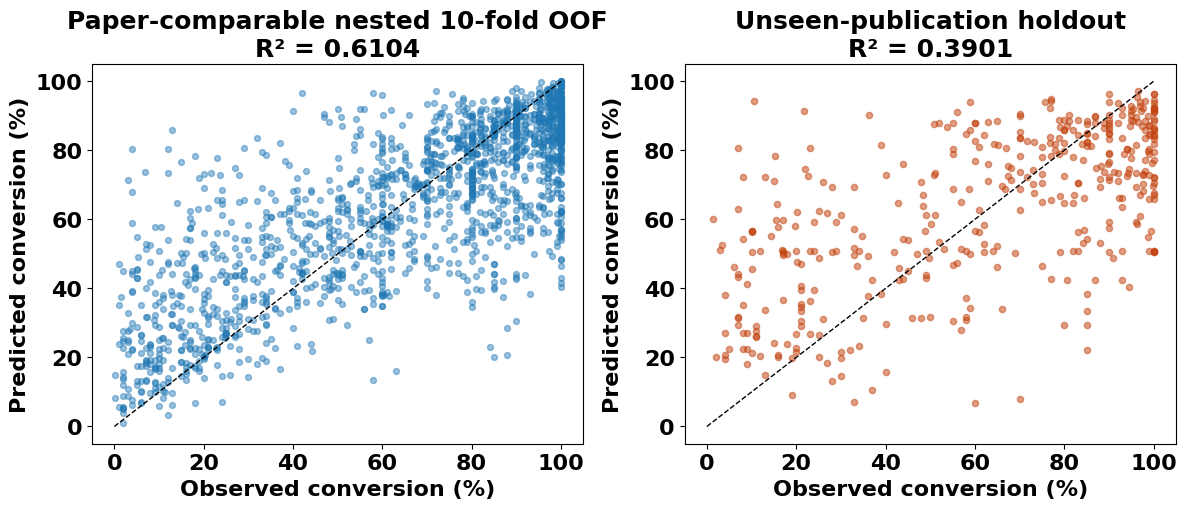

# Ammonia decomposition score-optimized model card

## Dataset
- SHA256: 4d8b25ef5522262e2700ae6ecdd50cd0984d07f3c48309d3d9aba46e2f209813
- Conversion rows used: 1662

## Conversion regression
- Primary paper-comparable nested shuffled 10-fold OOF R2: 0.6104
- Primary MAE: 14.2981 percentage points
- Primary RMSE: 19.3136 percentage points
- R2 >= 0.60 under interpolation protocol: True
- Training-only synthetic curve augmentation selected: True
- Final LightGBM/XGBoost/CatBoost weights: {'lightgbm': np.float64(0.6190476190476192), 'xgboost': np.float64(0.09523809523809523), 'catboost': np.float64(0.28571428571428564)}
- Strict unseen-publication holdout R2: 0.3901

## H2 classification — unseen-publication holdout
- ROC-AUC: 0.8586
- PR-AUC: 0.7931
- F1: 0.7551
- Balanced accuracy: 0.6957

## Interpretation boundary
The primary R2 allows rows from the same publication to occur in different folds,
matching the paper-style interpolation question. It is not evidence of performance
on an 

/kaggle/working/Ammonia_Paper_Approach_Best_R2_Results.zip

In [22]:
# Observed-versus-predicted diagnostics for both regression protocols.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
axes[0].scatter(y_conversion, row_oof_ensemble, alpha=0.45, s=18)
axes[0].plot([0, 100], [0, 100], "--", color="black", linewidth=1)
axes[0].set_title(f"Paper-comparable nested 10-fold OOF\nR² = {interpolation_metrics['r2']:.4f}")
axes[0].set_xlabel("Observed conversion (%)")
axes[0].set_ylabel("Predicted conversion (%)")

if strict_metrics is not None:
    axes[1].scatter(
        strict_output["conversion_pct"], strict_output["ensemble_prediction"],
        alpha=0.50, s=20, color="#C2410C"
    )
    axes[1].plot([0, 100], [0, 100], "--", color="black", linewidth=1)
    axes[1].set_title(f"Unseen-publication holdout\nR² = {strict_metrics['r2']:.4f}")
    axes[1].set_xlabel("Observed conversion (%)")
    axes[1].set_ylabel("Predicted conversion (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "conversion_dual_validation.png", dpi=220)
plt.show()

# Final conversion models use the selected representation and median nested weights.
if AUGMENTATION_SELECTED:
    final_training_frame = augment_training_curves(conversion_all)
    final_training_weight = final_training_frame["_sample_weight"].to_numpy()
else:
    final_training_frame = conversion_all.copy()
    final_training_weight = None

final_preprocessor = make_preprocessor()
x_all = final_preprocessor.fit_transform(final_training_frame[ACTIVE_MODEL_FEATURES])
final_y = final_training_frame["conversion_pct"].to_numpy(dtype=float)
final_lgb = make_lgb_regressor(9000)
final_xgb = make_xgb_regressor(9100)
final_cat = make_cat_regressor(9200)
final_lgb.fit(x_all, final_y, sample_weight=final_training_weight)
final_xgb.fit(x_all, final_y, sample_weight=final_training_weight)
final_cat.fit(
    catboost_matrix(final_training_frame), final_y,
    cat_features=CAT_FEATURES, sample_weight=final_training_weight,
)
joblib.dump(final_preprocessor, OUTPUT_DIR / "conversion_preprocessor.joblib")
joblib.dump(final_lgb, OUTPUT_DIR / "conversion_lightgbm.joblib")
joblib.dump(final_xgb, OUTPUT_DIR / "conversion_xgboost.joblib")
final_cat.save_model(str(OUTPUT_DIR / "conversion_catboost.cbm"))
with (OUTPUT_DIR / "conversion_blend_weights.json").open("w", encoding="utf-8") as handle:
    json.dump(FINAL_BLEND_WEIGHTS, handle, indent=2)

comparison_rows = [{"task": "conversion_regression", **interpolation_metrics}]
if strict_metrics is not None:
    comparison_rows.append({"task": "conversion_regression", **strict_metrics})
comparison_rows.append({"task": "h2_good_classification", **h2_metrics})
pd.DataFrame(comparison_rows).to_csv(OUTPUT_DIR / "PRIMARY_METRICS.csv", index=False)

strict_r2_text = f"{strict_metrics['r2']:.4f}" if strict_metrics is not None else "not run"
model_card = f"""# Ammonia decomposition score-optimized model card

## Dataset
- SHA256: {DATASET_SHA256}
- Conversion rows used: {len(conversion_all)}

## Conversion regression
- Primary paper-comparable nested shuffled 10-fold OOF R2: {interpolation_metrics['r2']:.4f}
- Primary MAE: {interpolation_metrics['mae']:.4f} percentage points
- Primary RMSE: {interpolation_metrics['rmse']:.4f} percentage points
- R2 >= 0.60 under interpolation protocol: {interpolation_metrics['target_met']}
- Training-only synthetic curve augmentation selected: {AUGMENTATION_SELECTED}
- Final LightGBM/XGBoost/CatBoost weights: {FINAL_BLEND_WEIGHTS}
- Strict unseen-publication holdout R2: {strict_r2_text}

## H2 classification — unseen-publication holdout
- ROC-AUC: {h2_metrics['roc_auc']:.4f}
- PR-AUC: {h2_metrics['pr_auc']:.4f}
- F1: {h2_metrics['f1']:.4f}
- Balanced accuracy: {h2_metrics['balanced_accuracy']:.4f}

## Interpretation boundary
The primary R2 allows rows from the same publication to occur in different folds,
matching the paper-style interpolation question. It is not evidence of performance
on an entirely unseen publication. Use only the strict group-holdout score for that
claim. Synthetic rows, if selected, are training-only and excluded from all metrics.
"""
(OUTPUT_DIR / "MODEL_CARD.md").write_text(model_card, encoding="utf-8")
print(model_card)

archive_base = OUTPUT_DIR.parent / f"{OUTPUT_DIR.name}_Results"
archive_file = Path(str(archive_base) + ".zip")
if archive_file.exists():
    archive_file.unlink()
archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=OUTPUT_DIR)
elapsed = (time.perf_counter() - PIPELINE_START) / 60
print(f"Runtime excluding package installation: {elapsed:.1f} minutes")
print("Result archive:", archive_path)
display(FileLink(archive_path))


# Q1 publication-figure suite

The following section runs after the original model pipeline and produces all 12 planned manuscript figures. Each figure is saved in **400-dpi PNG** and **vector PDF** formats under `paper_figures/`. Supporting plotting tables are also exported as CSV where relevant. The final cell rebuilds the result ZIP so it includes every figure.


In [23]:
from matplotlib import patches
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, precision_recall_curve, roc_curve,
)
import shap

FIGURE_DIR = OUTPUT_DIR / "paper_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "blue": "#2563EB", "navy": "#0F2D52", "cyan": "#0891B2",
    "orange": "#EA580C", "green": "#15803D", "red": "#B91C1C",
    "purple": "#7C3AED", "gray": "#64748B", "light": "#E2E8F0",
}
plt.rcParams.update({
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.labelsize": 11,
    "legend.fontsize": 9, "figure.titlesize": 14,
    "axes.spines.top": False, "axes.spines.right": False,
})


def save_paper_figure(fig, stem):
    png = FIGURE_DIR / f"{stem}.png"
    pdf = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=400, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print("Saved:", png.name, "and", pdf.name)


def panel_label(ax, label):
    ax.text(-0.10, 1.06, label, transform=ax.transAxes, fontsize=13,
            fontweight="bold", va="top")


def clean_feature_name(name):
    name = str(name).replace("num__", "").replace("cat__", "")
    return name.replace("_", " ")


def final_conversion_predict(frame):
    encoded = final_preprocessor.transform(frame[ACTIVE_MODEL_FEATURES])
    predictions = {
        "lightgbm": np.clip(final_lgb.predict(encoded), 0, 100),
        "xgboost": np.clip(final_xgb.predict(encoded), 0, 100),
        "catboost": np.clip(final_cat.predict(catboost_matrix(frame)), 0, 100),
    }
    return np.clip(sum(FINAL_BLEND_WEIGHTS[name] * predictions[name] for name in predictions), 0, 100)


print("Publication figures will be written to:", FIGURE_DIR)


Publication figures will be written to: /kaggle/working/Ammonia_Paper_Approach_Best_R2/paper_figures


## Figure 1 — Machine-learning framework for catalyst screening


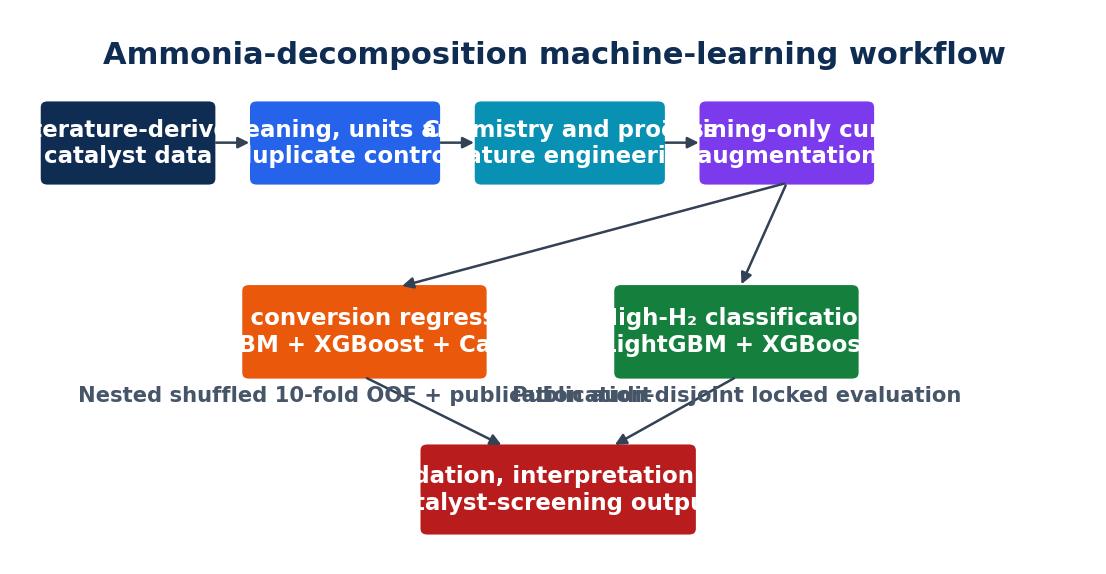

Saved: Figure_01_ML_framework.png and Figure_01_ML_framework.pdf


In [24]:
fig, ax = plt.subplots(figsize=(14, 7.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")

boxes = [
    (0.4, 5.5, 2.2, 1.15, "Literature-derived\ncatalyst data", COLORS["navy"]),
    (3.1, 5.5, 2.4, 1.15, "Cleaning, units and\nduplicate control", COLORS["blue"]),
    (6.0, 5.5, 2.4, 1.15, "Chemistry and process\nfeature engineering", COLORS["cyan"]),
    (8.9, 5.5, 2.2, 1.15, "Training-only curve\naugmentation", COLORS["purple"]),
    (3.0, 2.7, 3.1, 1.30, "NH₃ conversion regression\nLightGBM + XGBoost + CatBoost", COLORS["orange"]),
    (7.8, 2.7, 3.1, 1.30, "High-H₂ classification\nLightGBM + XGBoost", COLORS["green"]),
    (5.3, 0.45, 3.5, 1.25, "Validation, interpretation and\ncatalyst-screening outputs", COLORS["red"]),
]
for x, y, w, h, text_value, color in boxes:
    box = patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.10",
        facecolor=color, edgecolor="white", linewidth=1.5,
    )
    ax.add_patch(box)
    ax.text(x+w/2, y+h/2, text_value, ha="center", va="center",
            color="white", fontsize=10.5, fontweight="bold")

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#334155"))

arrow(2.6, 6.08, 3.1, 6.08)
arrow(5.5, 6.08, 6.0, 6.08)
arrow(8.4, 6.08, 8.9, 6.08)
arrow(10.0, 5.5, 5.0, 4.0)
arrow(10.0, 5.5, 9.4, 4.0)
arrow(4.55, 2.7, 6.35, 1.70)
arrow(9.35, 2.7, 7.75, 1.70)
ax.text(7.0, 7.35, "Ammonia-decomposition machine-learning workflow",
        ha="center", va="center", fontsize=16, fontweight="bold", color=COLORS["navy"])
ax.text(4.55, 2.35, "Nested shuffled 10-fold OOF + publication audit",
        ha="center", fontsize=9.2, color="#475569")
ax.text(9.35, 2.35, "Publication-disjoint locked evaluation",
        ha="center", fontsize=9.2, color="#475569")
save_paper_figure(fig, "Figure_01_ML_framework")


## Figure 2 — Dataset composition, missingness and catalyst space


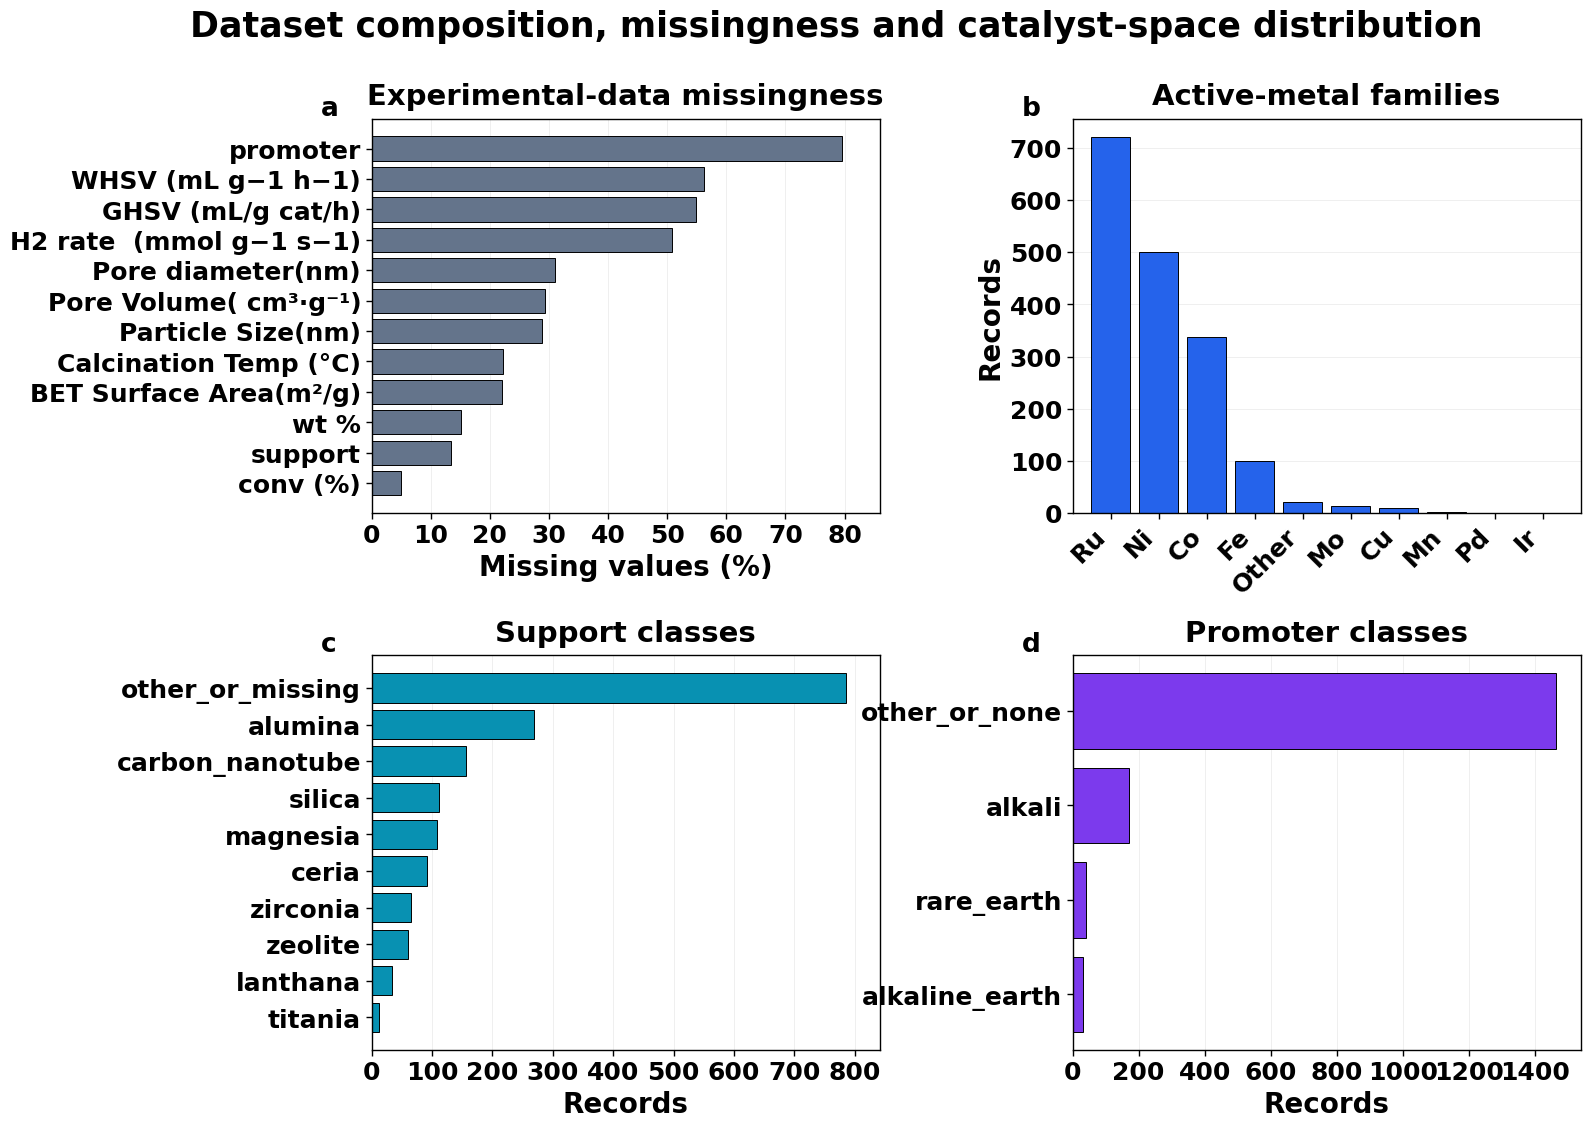

Saved: Figure_02_dataset_composition.png and Figure_02_dataset_composition.pdf


In [37]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(15.5, 11.5),
    gridspec_kw={"wspace": 0.38, "hspace": 0.36}
)

# -----------------------------
# (a) Missingness
# -----------------------------
missing = (
    raw_df
    .drop(columns=["_original_row_id"], errors="ignore")
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(12)
)

missing_labels = [str(x).replace("\n", " ") for x in missing.index]

axes[0, 0].barh(
    missing_labels[::-1],
    missing.values[::-1],
    color=COLORS["gray"],
    edgecolor="black",
    linewidth=0.7
)

axes[0, 0].set_xlabel("Missing values (%)", fontweight="bold")
axes[0, 0].set_title(
    "Experimental-data missingness",
    fontweight="bold",
    pad=10
)
axes[0, 0].set_xlim(0, max(85, missing.max() * 1.08))
axes[0, 0].grid(axis="x", alpha=0.20, linewidth=0.7)
panel_label(axes[0, 0], "a")


# -----------------------------
# (b) Active-metal families
# -----------------------------
active_counts = evaluation_df["active_family"].value_counts().head(10)

axes[0, 1].bar(
    active_counts.index.astype(str),
    active_counts.values,
    color=COLORS["blue"],
    edgecolor="black",
    linewidth=0.7
)

axes[0, 1].set_ylabel("Records", fontweight="bold")
axes[0, 1].set_title(
    "Active-metal families",
    fontweight="bold",
    pad=10
)

axes[0, 1].tick_params(axis="x", rotation=45)
for label in axes[0, 1].get_xticklabels():
    label.set_horizontalalignment("right")

axes[0, 1].grid(axis="y", alpha=0.20, linewidth=0.7)
axes[0, 1].margins(x=0.04)
panel_label(axes[0, 1], "b")


# -----------------------------
# (c) Support classes
# -----------------------------
support_counts = evaluation_df["support_class"].value_counts().head(10)

axes[1, 0].barh(
    support_counts.index.astype(str)[::-1],
    support_counts.values[::-1],
    color=COLORS["cyan"],
    edgecolor="black",
    linewidth=0.7
)

axes[1, 0].set_xlabel("Records", fontweight="bold")
axes[1, 0].set_title(
    "Support classes",
    fontweight="bold",
    pad=10
)
axes[1, 0].grid(axis="x", alpha=0.20, linewidth=0.7)
axes[1, 0].set_xlim(0, support_counts.max() * 1.07)
panel_label(axes[1, 0], "c")


# -----------------------------
# (d) Promoter classes
# -----------------------------
promoter_counts = evaluation_df["promoter_class"].value_counts().head(10)

axes[1, 1].barh(
    promoter_counts.index.astype(str)[::-1],
    promoter_counts.values[::-1],
    color=COLORS["purple"],
    edgecolor="black",
    linewidth=0.7
)

axes[1, 1].set_xlabel("Records", fontweight="bold")
axes[1, 1].set_title(
    "Promoter classes",
    fontweight="bold",
    pad=10
)
axes[1, 1].grid(axis="x", alpha=0.20, linewidth=0.7)
axes[1, 1].set_xlim(0, promoter_counts.max() * 1.05)
panel_label(axes[1, 1], "d")


# -----------------------------
# Global styling
# -----------------------------
for ax in axes.flat:

    # Full rectangular borders
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    # Bold tick labels
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
        width=1.0,
        length=4
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    # Keep grid behind bars
    ax.set_axisbelow(True)

    # Axis labels
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")

    # Panel title size
    ax.title.set_fontsize(15)
    ax.title.set_fontweight("bold")


fig.suptitle(
    "Dataset composition, missingness and catalyst-space distribution",
    fontsize=19,
    fontweight="bold",
    y=0.995
)

# Better control than tight_layout alone
fig.subplots_adjust(
    left=0.20,
    right=0.98,
    bottom=0.09,
    top=0.90,
    wspace=0.53,
    hspace=0.38
)

save_paper_figure(fig, "Figure_02_dataset_composition")

## Figure 3 — Target distributions across operating conditions


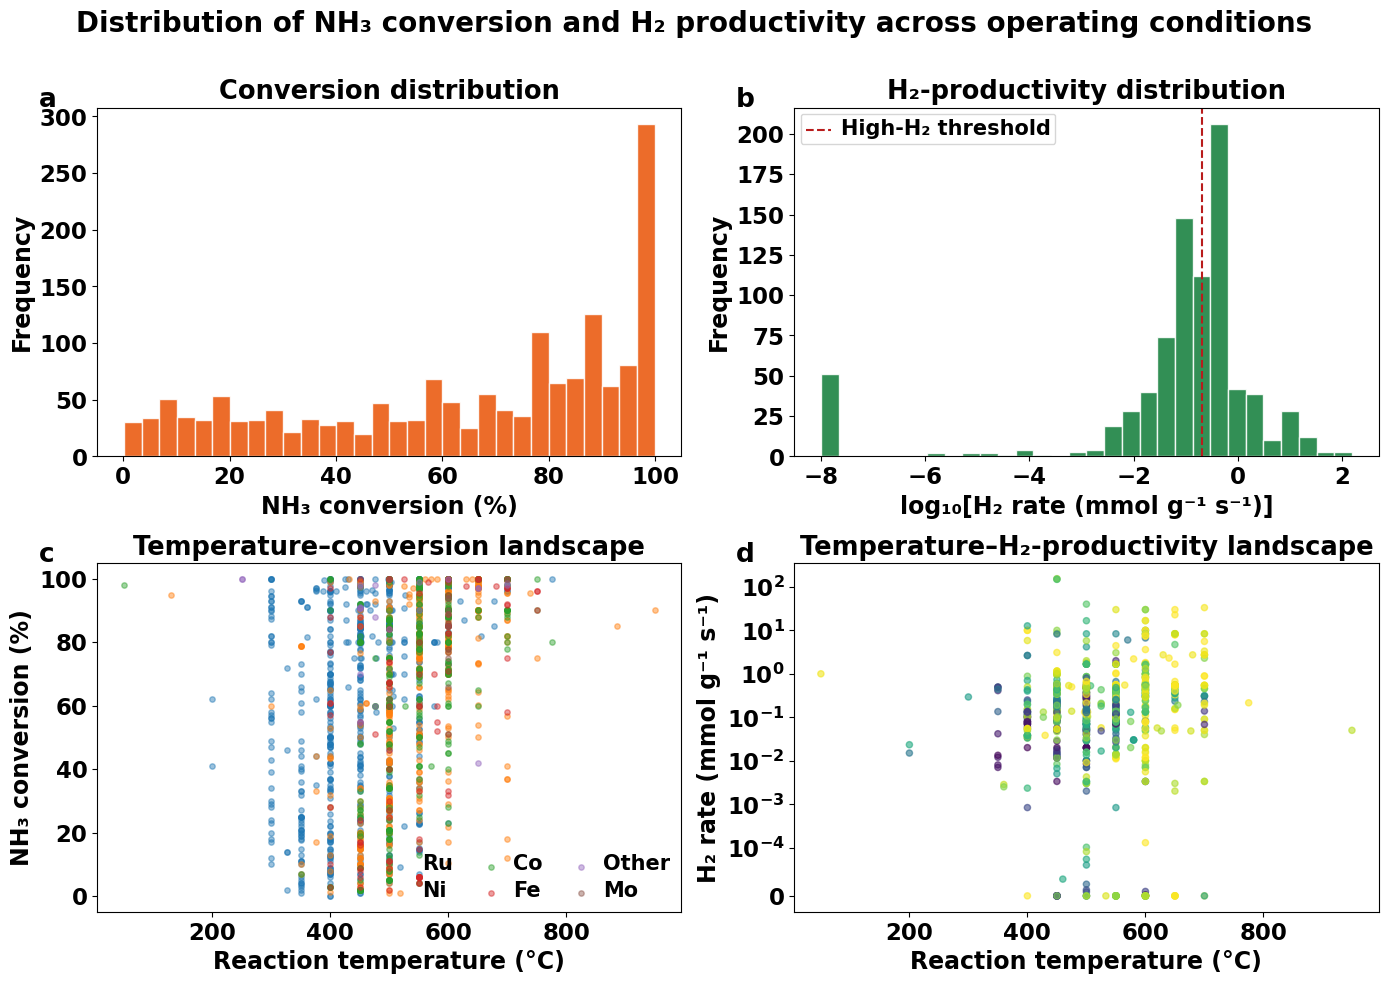

Saved: Figure_03_target_distributions.png and Figure_03_target_distributions.pdf


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(conversion_all["conversion_pct"], bins=30, color=COLORS["orange"], alpha=0.88, edgecolor="white")
axes[0, 0].set_xlabel("NH₃ conversion (%)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Conversion distribution")
panel_label(axes[0, 0], "a")

log_h2 = np.log10(np.clip(h2_rate_all["h2_rate_mmol_g_s"].to_numpy(dtype=float), 1e-8, None))
axes[0, 1].hist(log_h2, bins=30, color=COLORS["green"], alpha=0.88, edgecolor="white")
axes[0, 1].axvline(np.log10(max(H2_THRESHOLD, 1e-8)), color=COLORS["red"], linestyle="--", label="High-H₂ threshold")
axes[0, 1].set_xlabel("log₁₀[H₂ rate (mmol g⁻¹ s⁻¹)]")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("H₂-productivity distribution")
axes[0, 1].legend()
panel_label(axes[0, 1], "b")

families = conversion_all["active_family"].value_counts().head(6).index
for family in families:
    part = conversion_all[conversion_all["active_family"] == family]
    axes[1, 0].scatter(part["temperature_c"], part["conversion_pct"], s=15, alpha=0.45, label=family)
axes[1, 0].set_xlabel("Reaction temperature (°C)")
axes[1, 0].set_ylabel("NH₃ conversion (%)")
axes[1, 0].set_title("Temperature–conversion landscape")
axes[1, 0].legend(ncol=3, frameon=False)
panel_label(axes[1, 0], "c")

axes[1, 1].scatter(h2_rate_all["temperature_c"], h2_rate_all["h2_rate_mmol_g_s"],
                   c=h2_rate_all["conversion_pct"], cmap="viridis", s=20, alpha=0.60)
axes[1, 1].set_yscale("symlog", linthresh=1e-4)
axes[1, 1].set_xlabel("Reaction temperature (°C)")
axes[1, 1].set_ylabel("H₂ rate (mmol g⁻¹ s⁻¹)")
axes[1, 1].set_title("Temperature–H₂-productivity landscape")
panel_label(axes[1, 1], "d")

fig.suptitle("Distribution of NH₃ conversion and H₂ productivity across operating conditions", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_paper_figure(fig, "Figure_03_target_distributions")


## Figure 4 — Effect of training-only synthetic augmentation


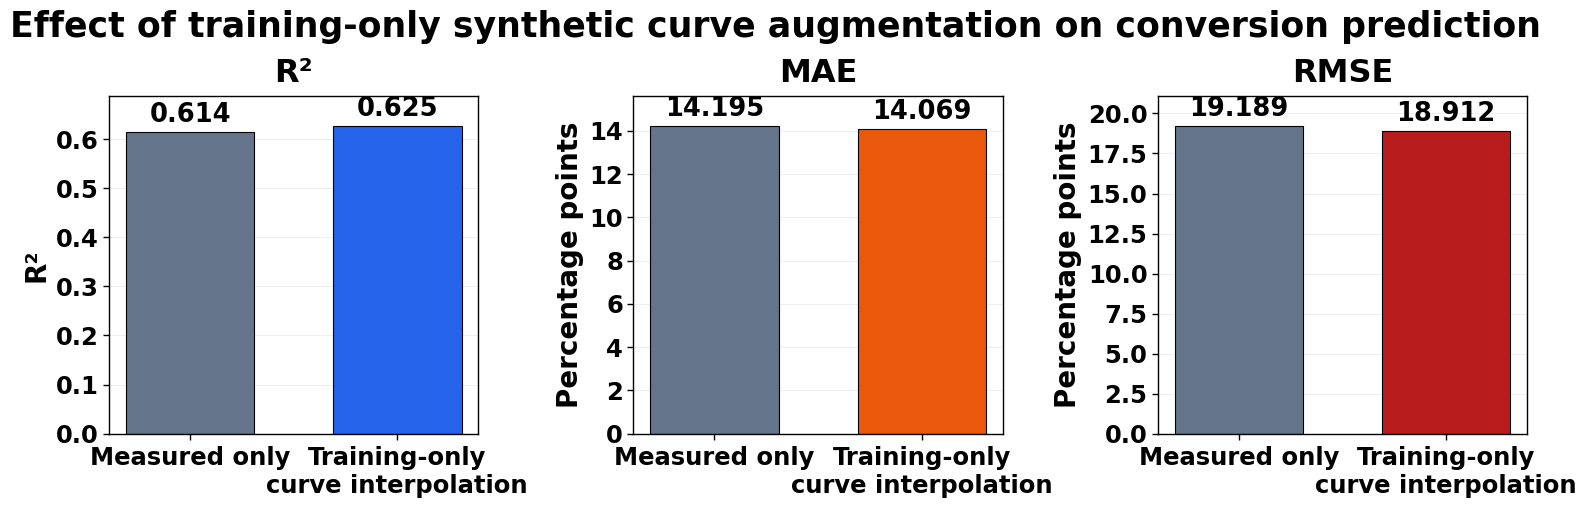

Saved: Figure_04_augmentation_effect.png and Figure_04_augmentation_effect.pdf


In [43]:
audit = augmentation_audit.copy()

labels = [
    "Measured only",
    "Training-only\ncurve interpolation"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15.5, 5.2),
    gridspec_kw={"wspace": 0.42}
)

metrics = ["r2", "mae", "rmse"]
titles  = ["R²", "MAE", "RMSE"]
colors  = [COLORS["blue"], COLORS["orange"], COLORS["red"]]

for ax, metric, title, color in zip(
    axes, metrics, titles, colors
):
    values = audit[metric].to_numpy(dtype=float)

    bars = ax.bar(
        labels,
        values,
        color=[COLORS["gray"], color],
        width=0.62,
        edgecolor="black",
        linewidth=0.8
    )

    # -----------------------------------------------------
    # Titles and axis labels
    # -----------------------------------------------------
    ax.set_title(
        title,
        fontsize=17,
        fontweight="bold",
        pad=10
    )

    ax.set_ylabel(
        title if metric == "r2" else "Percentage points",
        fontsize=14,
        fontweight="bold"
    )

    # -----------------------------------------------------
    # Sensible axis limits + headroom
    # -----------------------------------------------------
    if metric == "r2":
        ymax = max(values) * 1.10
        ax.set_ylim(0, max(0.68, ymax))
    else:
        ymax = max(values) * 1.10
        ax.set_ylim(0, ymax)

    # -----------------------------------------------------
    # Value labels
    # -----------------------------------------------------
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    offset = y_range * 0.012

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=12.5,
            fontweight="bold"
        )

    # -----------------------------------------------------
    # Grid
    # -----------------------------------------------------
    ax.grid(
        axis="y",
        alpha=0.20,
        linewidth=0.7
    )
    ax.set_axisbelow(True)

    # -----------------------------------------------------
    # Full border/spines
    # -----------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    # -----------------------------------------------------
    # Tick styling
    # -----------------------------------------------------
    ax.tick_params(
        axis="y",
        labelsize=11.5,
        width=1.0,
        length=4
    )

    ax.tick_params(
        axis="x",
        labelsize=11.5,
        width=1.0,
        length=4,
        pad=5
    )

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")


# =========================================================
# Main title
# =========================================================
fig.suptitle(
    "Effect of training-only synthetic curve augmentation on conversion prediction",
    fontsize=19,
    fontweight="bold",
    y=0.985
)

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.17,
    top=0.82,
    wspace=0.40
)

save_paper_figure(
    fig,
    "Figure_04_augmentation_effect"
)

## Figure 5 — Base-model and ensemble comparison


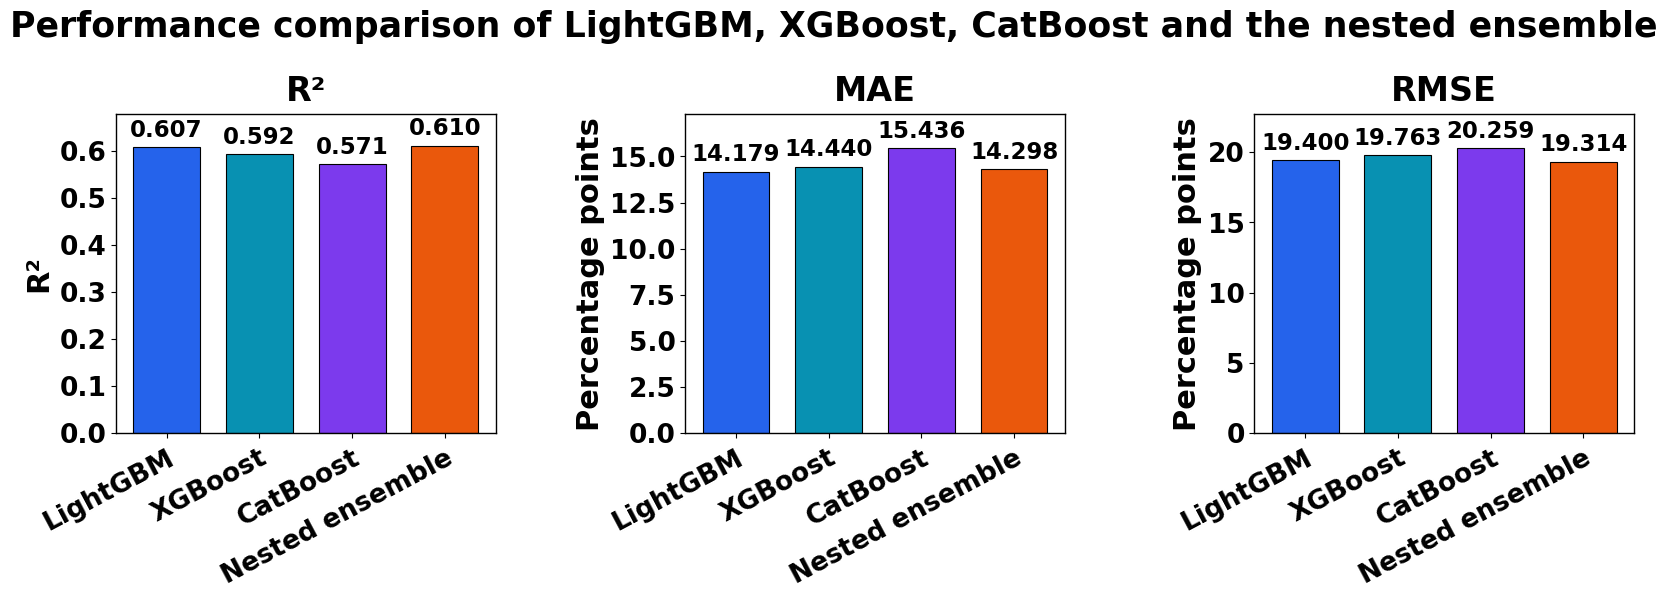

Saved: Figure_05_model_comparison.png and Figure_05_model_comparison.pdf


In [45]:
comparison = pd.DataFrame(individual_model_metrics).copy()

comparison["display_model"] = comparison["model"].replace({
    "lightgbm": "LightGBM",
    "xgboost": "XGBoost",
    "catboost": "CatBoost",
    "nested_blend": "Nested ensemble",
})

comparison.to_csv(
    FIGURE_DIR / "Figure_05_model_comparison_data.csv",
    index=False
)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.8))

palette = [
    COLORS["blue"],
    COLORS["cyan"],
    COLORS["purple"],
    COLORS["orange"]
]

metrics = ["r2", "mae", "rmse"]
titles = ["R²", "MAE", "RMSE"]
ylabels = ["R²", "Percentage points", "Percentage points"]

for ax, metric, title, ylabel in zip(
    axes, metrics, titles, ylabels
):
    values = comparison[metric].astype(float)

    bars = ax.bar(
        comparison["display_model"],
        values,
        color=palette,
        width=0.72,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=10
    )

    ax.set_ylabel(
        ylabel,
        fontsize=16,
        fontweight="bold"
    )

    ax.tick_params(
        axis="x",
        labelsize=13,
        pad=5
    )

    for label in ax.get_xticklabels():
        label.set_rotation(28)
        label.set_horizontalalignment("right")
        label.set_rotation_mode("anchor")
        label.set_fontweight("bold")

    ax.tick_params(
        axis="y",
        labelsize=13
    )

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    # Extra headroom for value labels
    if metric == "r2":
        ax.set_ylim(0, max(values.max() * 1.11, 0.66))
    else:
        ax.set_ylim(0, values.max() * 1.12)

    # Values above bars — slightly smaller for cleaner alignment
    for bar, value in zip(bars, values):
        ax.annotate(
            f"{value:.3f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            clip_on=False
        )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

fig.suptitle(
    "Performance comparison of LightGBM, XGBoost, CatBoost and the nested ensemble",
    fontsize=19,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.25,
    top=0.80,
    wspace=0.50
)

save_paper_figure(
    fig,
    "Figure_05_model_comparison"
)

## Figure 6 — Observed versus predicted NH₃ conversion


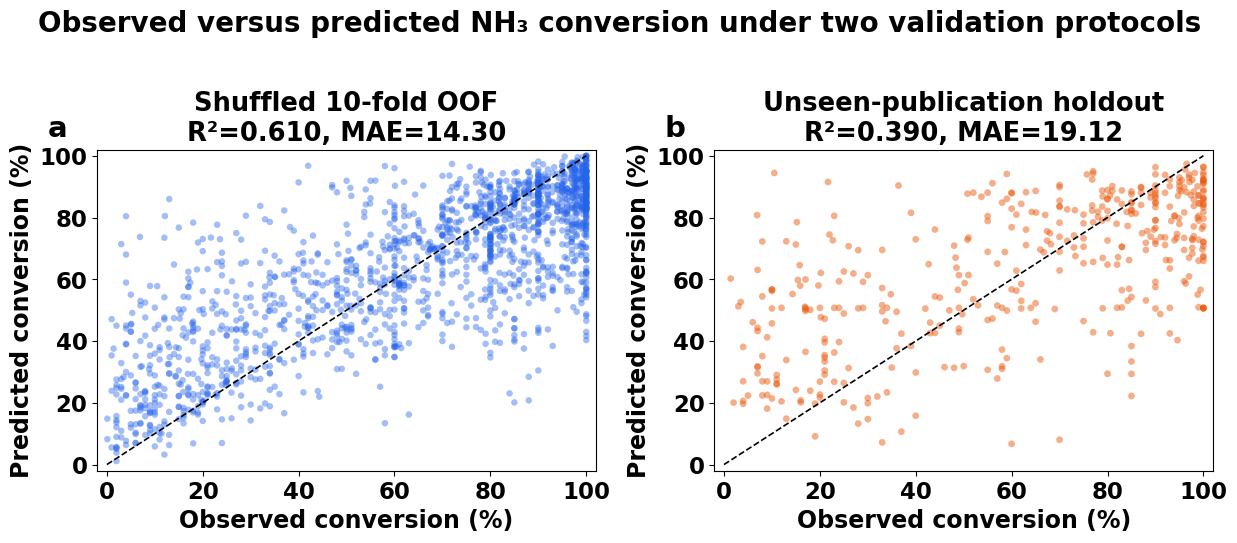

Saved: Figure_06_conversion_parity.png and Figure_06_conversion_parity.pdf


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))

axes[0].scatter(
    y_conversion, row_oof_ensemble,
    s=22, alpha=0.42,
    color=COLORS["blue"],
    edgecolors="none"
)
axes[0].plot([0, 100], [0, 100], "--", color="black", lw=1.2)
axes[0].set(
    xlabel="Observed conversion (%)",
    ylabel="Predicted conversion (%)",
    title=f"Shuffled 10-fold OOF\n"
          f"R²={interpolation_metrics['r2']:.3f}, "
          f"MAE={interpolation_metrics['mae']:.2f}"
)

# Panel label moved further upward and font size reduced
axes[0].text(
    -0.10, 1.065, "a",
    transform=axes[0].transAxes,
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="center",
    clip_on=False
)

if strict_metrics is not None:
    axes[1].scatter(
        strict_output["conversion_pct"],
        strict_output["ensemble_prediction"],
        s=24, alpha=0.48,
        color=COLORS["orange"],
        edgecolors="none"
    )
    axes[1].plot([0, 100], [0, 100], "--", color="black", lw=1.2)
    axes[1].set(
        xlabel="Observed conversion (%)",
        ylabel="Predicted conversion (%)",
        title=f"Unseen-publication holdout\n"
              f"R²={strict_metrics['r2']:.3f}, "
              f"MAE={strict_metrics['mae']:.2f}"
    )

# Panel label moved further upward and font size reduced
axes[1].text(
    -0.10, 1.065, "b",
    transform=axes[1].transAxes,
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="center",
    clip_on=False
)

for ax in axes:
    ax.set_xlim(-2, 102)
    ax.set_ylim(-2, 102)

fig.suptitle(
    "Observed versus predicted NH₃ conversion under two validation protocols",
    fontweight="bold"
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
save_paper_figure(fig, "Figure_06_conversion_parity")

## Figure 7 — Fold-wise performance and residual diagnostics


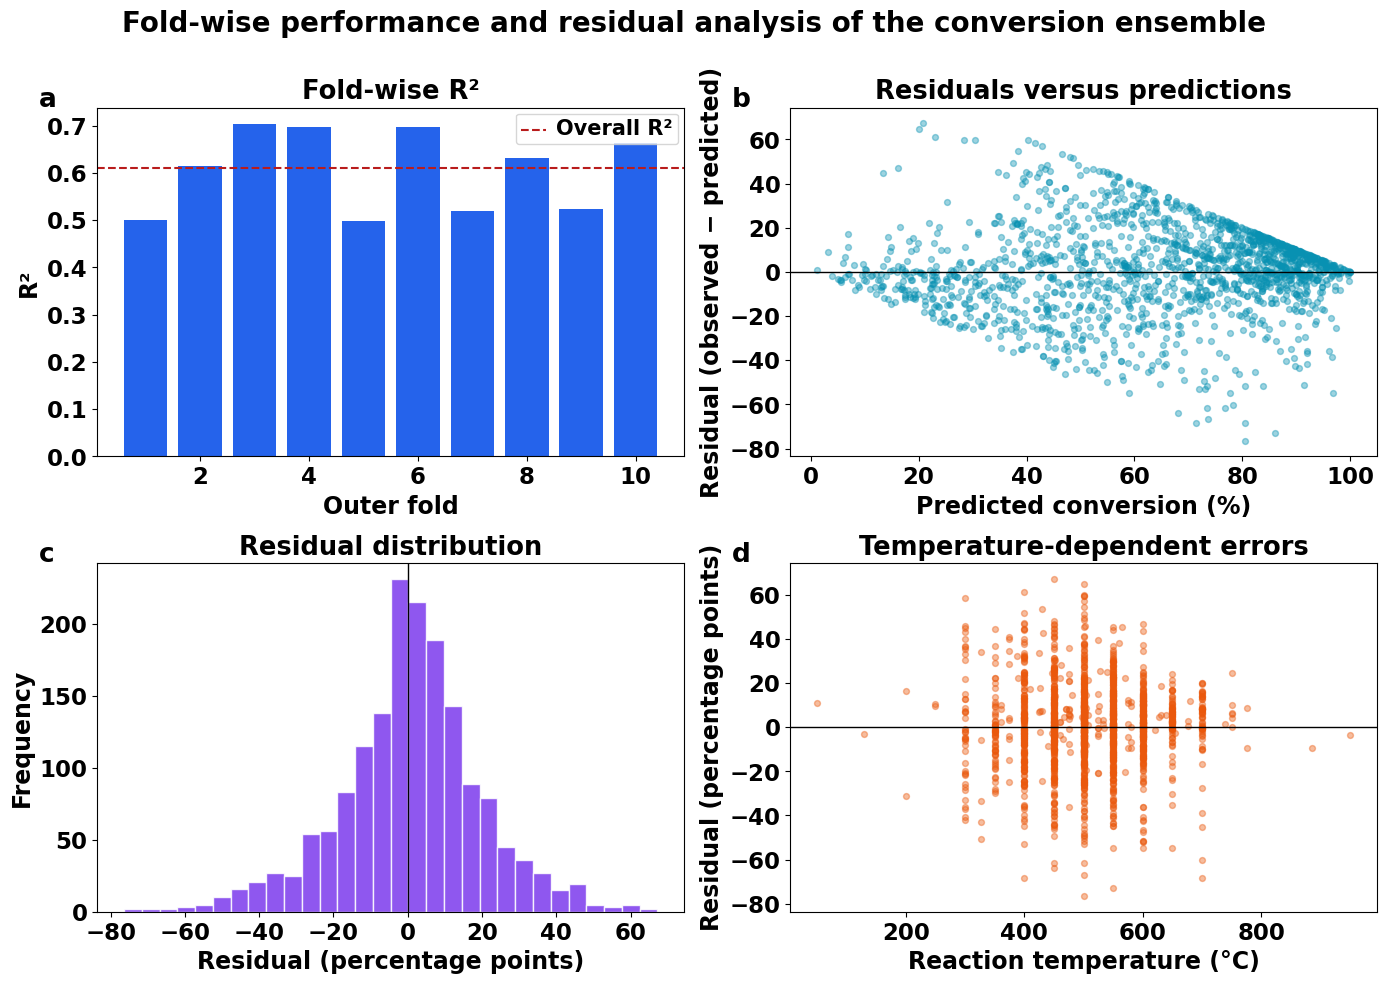

Saved: Figure_07_fold_residual_analysis.png and Figure_07_fold_residual_analysis.pdf


In [30]:
fold_table = pd.DataFrame(row_fold_metrics)
residual = y_conversion - row_oof_ensemble
figure7_data = row_oof_table.copy()
figure7_data["residual"] = residual
figure7_data.to_csv(FIGURE_DIR / "Figure_07_residual_data.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].bar(fold_table["fold"], fold_table["r2"], color=COLORS["blue"])
axes[0, 0].axhline(interpolation_metrics["r2"], color=COLORS["red"], linestyle="--", label="Overall R²")
axes[0, 0].set(xlabel="Outer fold", ylabel="R²", title="Fold-wise R²")
axes[0, 0].legend()
panel_label(axes[0, 0], "a")

axes[0, 1].scatter(row_oof_ensemble, residual, s=18, alpha=0.40, color=COLORS["cyan"])
axes[0, 1].axhline(0, color="black", lw=1)
axes[0, 1].set(xlabel="Predicted conversion (%)", ylabel="Residual (observed − predicted)", title="Residuals versus predictions")
panel_label(axes[0, 1], "b")

axes[1, 0].hist(residual, bins=30, color=COLORS["purple"], alpha=0.85, edgecolor="white")
axes[1, 0].axvline(0, color="black", lw=1)
axes[1, 0].set(xlabel="Residual (percentage points)", ylabel="Frequency", title="Residual distribution")
panel_label(axes[1, 0], "c")

axes[1, 1].scatter(conversion_all["temperature_c"], residual, s=18, alpha=0.40, color=COLORS["orange"])
axes[1, 1].axhline(0, color="black", lw=1)
axes[1, 1].set(xlabel="Reaction temperature (°C)", ylabel="Residual (percentage points)", title="Temperature-dependent errors")
panel_label(axes[1, 1], "d")

fig.suptitle("Fold-wise performance and residual analysis of the conversion ensemble", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_paper_figure(fig, "Figure_07_fold_residual_analysis")


## Figure 8 — ROC and precision–recall curves


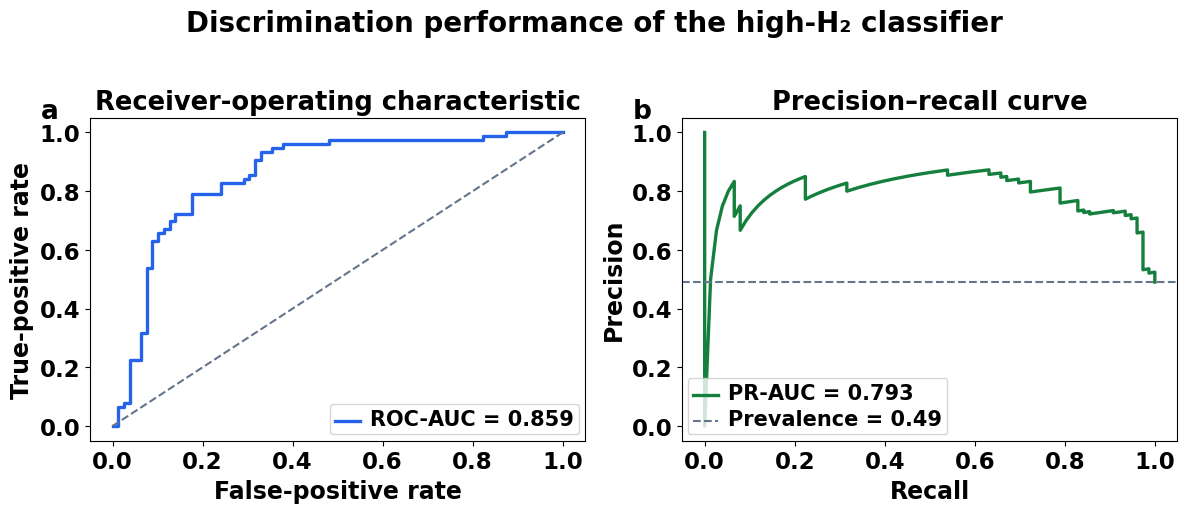

Saved: Figure_08_H2_ROC_PR_curves.png and Figure_08_H2_ROC_PR_curves.pdf


In [31]:
y_h2_locked = h2_locked["h2_good_label"].to_numpy(dtype=int)
fpr, tpr, _ = roc_curve(y_h2_locked, h2_probability)
precision_curve, recall_curve, _ = precision_recall_curve(y_h2_locked, h2_probability)
curve_data = pd.concat([
    pd.DataFrame({"curve": "ROC", "x": fpr, "y": tpr}),
    pd.DataFrame({"curve": "PR", "x": recall_curve, "y": precision_curve}),
], ignore_index=True)
curve_data.to_csv(FIGURE_DIR / "Figure_08_ROC_PR_curve_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
axes[0].plot(fpr, tpr, color=COLORS["blue"], lw=2.4, label=f"ROC-AUC = {h2_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color=COLORS["gray"])
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="Receiver-operating characteristic")
axes[0].legend(loc="lower right")
panel_label(axes[0], "a")

baseline = y_h2_locked.mean()
axes[1].plot(recall_curve, precision_curve, color=COLORS["green"], lw=2.4, label=f"PR-AUC = {h2_metrics['pr_auc']:.3f}")
axes[1].axhline(baseline, linestyle="--", color=COLORS["gray"], label=f"Prevalence = {baseline:.2f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curve")
axes[1].legend(loc="lower left")
panel_label(axes[1], "b")
fig.suptitle("Discrimination performance of the high-H₂ classifier", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_paper_figure(fig, "Figure_08_H2_ROC_PR_curves")


## Figure 9 — Confusion matrix and probability calibration


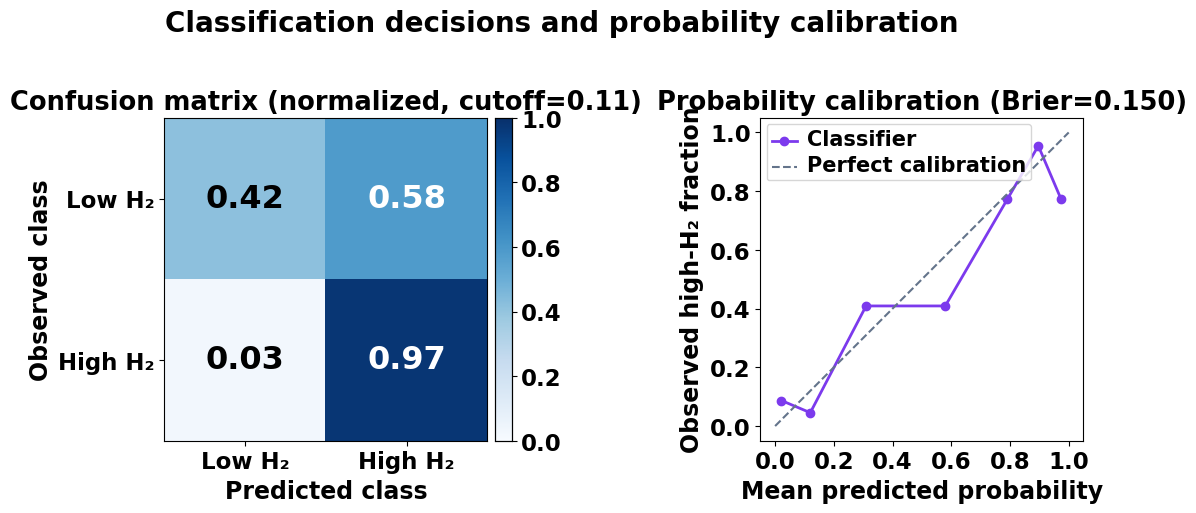

Saved: Figure_09_H2_confusion_calibration.png and Figure_09_H2_confusion_calibration.pdf


In [55]:
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

h2_predicted_label = (h2_probability >= H2_CUTOFF).astype(int)

# Raw confusion matrix
cm_counts = confusion_matrix(y_h2_locked, h2_predicted_label, labels=[0, 1])

# Row-normalized confusion matrix
cm = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

prob_true, prob_pred = calibration_curve(
    y_h2_locked, h2_probability, n_bins=7, strategy="quantile"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# --- Left panel: normalized confusion matrix ---
image_cm = axes[0].imshow(cm, cmap="Blues", vmin=0, vmax=1)

for i in range(2):
    for j in range(2):
        axes[0].text(
            j, i, f"{cm[i, j]:.2f}",
            ha="center", va="center",
            fontsize=17,
            color="white" if cm[i, j] > 0.5 else "black"
        )

axes[0].set_xticks([0, 1], ["Low H₂", "High H₂"])
axes[0].set_yticks([0, 1], ["Low H₂", "High H₂"])
axes[0].set(
    xlabel="Predicted class",
    ylabel="Observed class",
    title=f"Confusion matrix (normalized, cutoff={H2_CUTOFF:.2f})"
)
axes[0].set_box_aspect(1)

# Colorbar without shrinking the subplot differently
divider = make_axes_locatable(axes[0])
cax = divider.append_axes("right", size="5%", pad=0.08)
fig.colorbar(image_cm, cax=cax)

# If you still want panel labels:
# axes[0].text(-0.12, 1.05, "a", transform=axes[0].transAxes,
#              fontsize=15, fontweight="bold", ha="left", va="center", clip_on=False)

# --- Right panel: calibration curve ---
axes[1].plot(
    prob_pred, prob_true, "o-",
    color=COLORS["purple"],
    lw=2,
    label="Classifier"
)
axes[1].plot(
    [0, 1], [0, 1], "--",
    color=COLORS["gray"],
    label="Perfect calibration"
)
axes[1].set(
    xlabel="Mean predicted probability",
    ylabel="Observed high-H₂ fraction",
    title=f"Probability calibration (Brier={h2_metrics['brier']:.3f})"
)
axes[1].legend()
axes[1].set_box_aspect(1)

# If you still want panel labels:
# axes[1].text(-0.12, 1.05, "b", transform=axes[1].transAxes,
#              fontsize=15, fontweight="bold", ha="left", va="center", clip_on=False)

fig.suptitle("Classification decisions and probability calibration", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_paper_figure(fig, "Figure_09_H2_confusion_calibration")

## Figure 10 — SHAP-based global feature importance


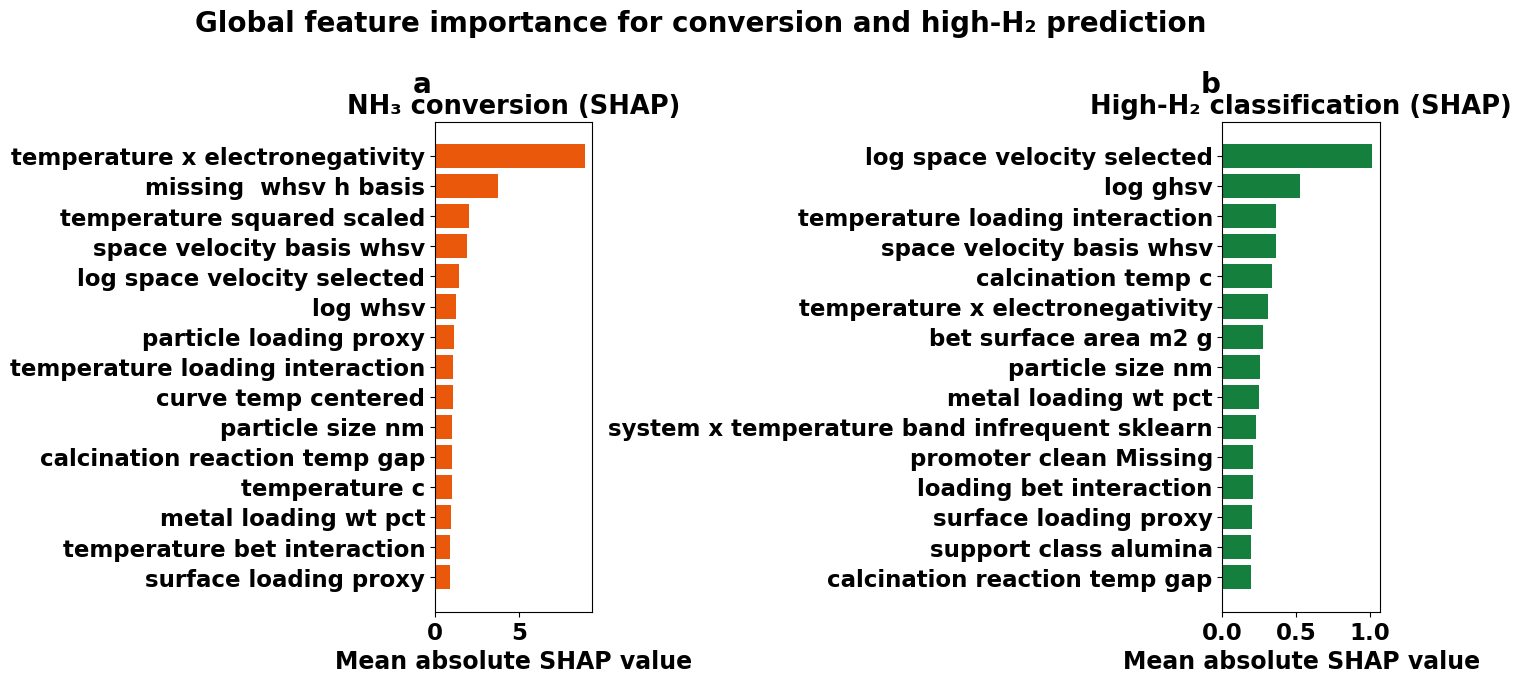

Saved: Figure_10_SHAP_global_importance.png and Figure_10_SHAP_global_importance.pdf


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, table, title, color, label in [
    (axes[0], conv_shap, f"NH₃ conversion ({conv_method})", COLORS["orange"], "a"),
    (axes[1], h2_shap, f"High-H₂ classification ({h2_method})", COLORS["green"], "b"),
]:
    top = table.head(15).sort_values("mean_abs_shap")

    ax.barh(
        [clean_feature_name(x) for x in top["feature"]],
        top["mean_abs_shap"],
        color=color
    )

    ax.set_xlabel(
        "Mean absolute SHAP value"
        if "SHAP" in title and "fallback" not in title
        else "Feature importance"
    )

    ax.set_title(title)

    # Panel label moved further upward and reduced in size
    ax.text(
        -0.14, 1.075, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="center",
        clip_on=False
    )

fig.suptitle(
    "Global feature importance for conversion and high-H₂ prediction",
    fontweight="bold"
)

# More room between panels for long feature labels
fig.subplots_adjust(
    left=0.31,
    right=0.985,
    bottom=0.12,
    top=0.82,
    wspace=4.0
)

save_paper_figure(fig, "Figure_10_SHAP_global_importance")

## Figure 11 — Feature-effect profiles


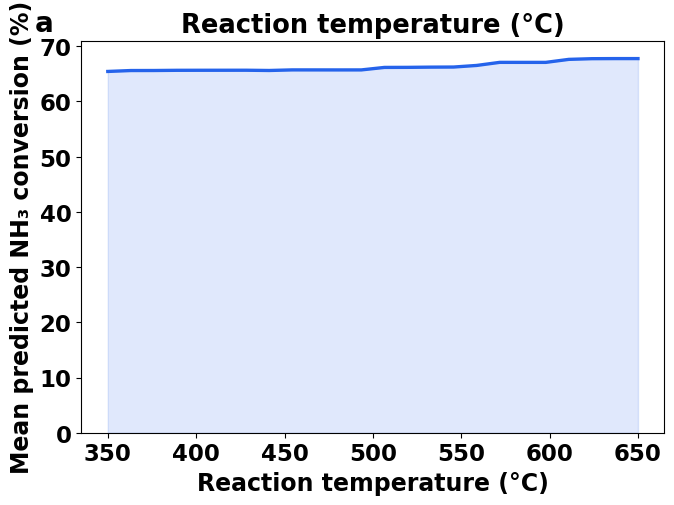

Saved: Figure_11a_temperature_effect.png and Figure_11a_temperature_effect.pdf


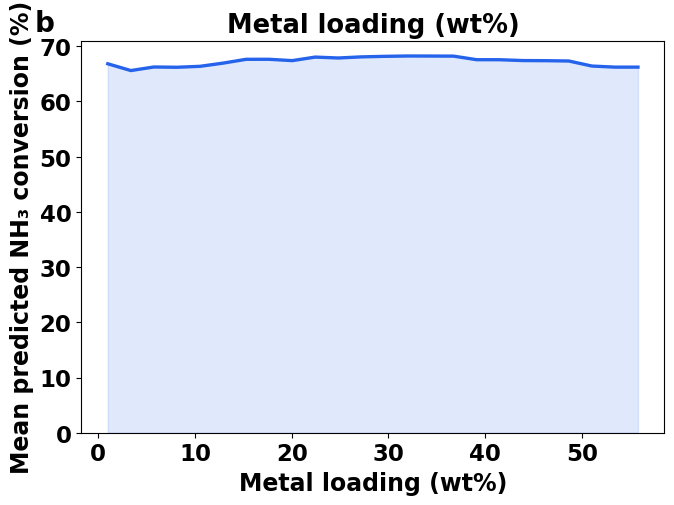

Saved: Figure_11b_metal_loading_effect.png and Figure_11b_metal_loading_effect.pdf


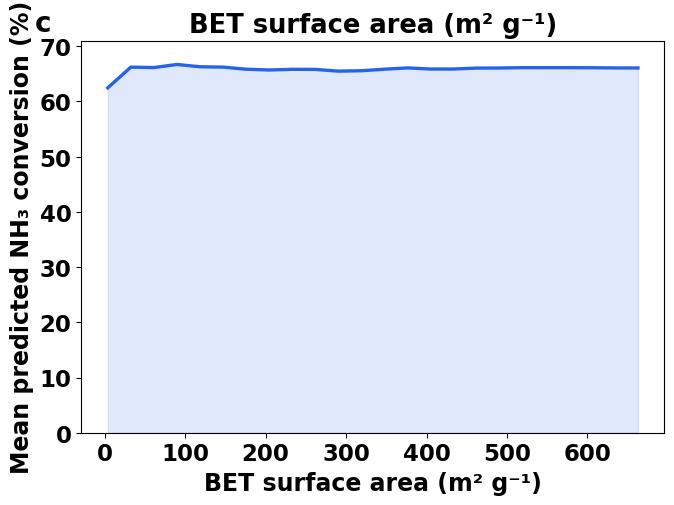

Saved: Figure_11c_BET_surface_area_effect.png and Figure_11c_BET_surface_area_effect.pdf


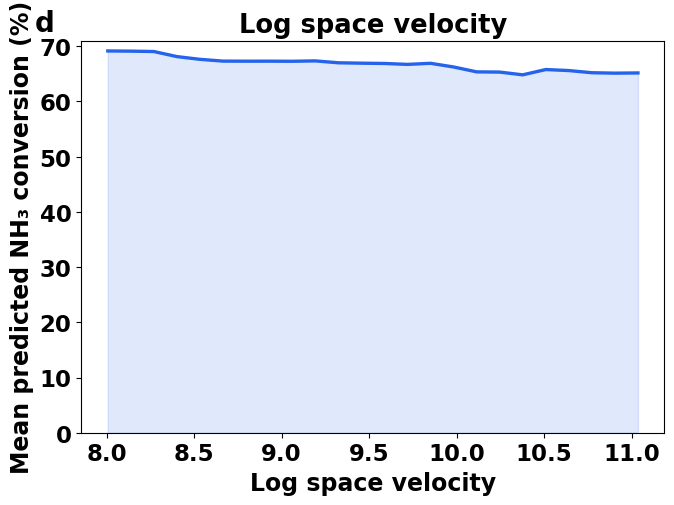

Saved: Figure_11d_log_space_velocity_effect.png and Figure_11d_log_space_velocity_effect.pdf


In [61]:
pdp_features = [
    ("temperature_c", "Reaction temperature (°C)", "a", "Figure_11a_temperature_effect"),
    ("metal_loading_wt_pct", "Metal loading (wt%)", "b", "Figure_11b_metal_loading_effect"),
    ("bet_surface_area_m2_g", "BET surface area (m² g⁻¹)", "c", "Figure_11c_BET_surface_area_effect"),
    ("log_space_velocity_selected", "Log space velocity", "d", "Figure_11d_log_space_velocity_effect"),
]

pdp_sample = conversion_all.sample(
    n=min(500, len(conversion_all)),
    random_state=RANDOM_SEED + 11
).copy()

pdp_rows = []

for feature, label, letter, figure_name in pdp_features:

    values = pd.to_numeric(
        pdp_sample[feature],
        errors="coerce"
    )

    finite = values[np.isfinite(values)]

    # Create ONE individual figure
    fig, ax = plt.subplots(figsize=(7.2, 5.6))

    if len(finite) < 10:

        ax.text(
            0.5,
            0.5,
            "Insufficient reported data",
            ha="center",
            va="center",
            transform=ax.transAxes
        )

        ax.set_title(label)

    else:

        low, high = np.quantile(
            finite,
            [0.05, 0.95]
        )

        grid = np.linspace(
            low,
            high,
            24
        )

        mean_prediction = []

        for value in grid:

            modified = pdp_sample.copy()
            modified[feature] = value

            prediction = float(
                np.mean(
                    final_conversion_predict(modified)
                )
            )

            mean_prediction.append(prediction)

            pdp_rows.append({
                "feature": feature,
                "grid_value": value,
                "mean_predicted_conversion": prediction
            })

        ax.plot(
            grid,
            mean_prediction,
            color=COLORS["blue"],
            lw=2.4
        )

        ax.fill_between(
            grid,
            mean_prediction,
            alpha=0.14,
            color=COLORS["blue"]
        )

        ax.set(
            xlabel=label,
            ylabel="Mean predicted NH₃ conversion (%)",
            title=label
        )

    # Smaller panel label and placed above the axes
    ax.text(
        -0.08,
        1.045,
        letter,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="center",
        clip_on=False
    )

    # Consistent y-axis for comparison across all four figures
    ax.set_ylim(0, 71)

    # Clean individual-figure alignment
    fig.subplots_adjust(
        left=0.16,
        right=0.97,
        bottom=0.16,
        top=0.86
    )

    save_paper_figure(
        fig,
        figure_name
    )

    plt.close(fig)


# Save all PDP numerical data together
pd.DataFrame(pdp_rows).to_csv(
    FIGURE_DIR / "Figure_11_partial_dependence_data.csv",
    index=False
)

## Figure 12 — Integrated catalyst-screening map


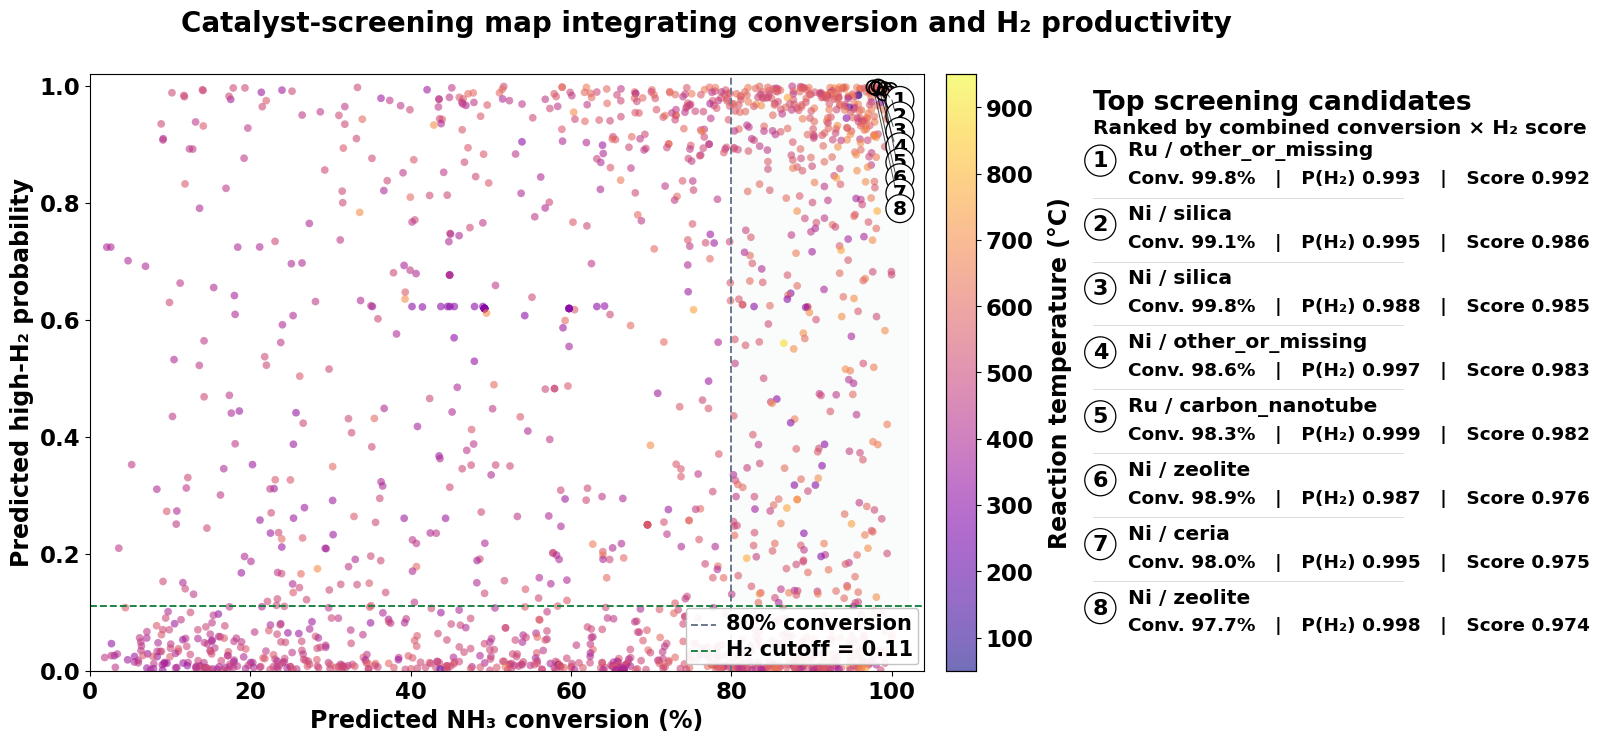

Saved: Figure_12_integrated_screening_map.png and Figure_12_integrated_screening_map.pdf


In [64]:
import numpy as np
import textwrap
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# ============================================================
# FIGURE 12 — Publication-style integrated screening map
# ============================================================

top_candidates = screening.head(8).copy().reset_index(drop=True)

fig = plt.figure(figsize=(14.5, 7.6))

# Main plot + dedicated candidate information panel
gs = GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[4.8, 1.75],
    wspace=0.18
)

ax = fig.add_subplot(gs[0, 0])
ax_info = fig.add_subplot(gs[0, 1])


# ============================================================
# MAIN SCATTER
# ============================================================

scatter = ax.scatter(
    screening["predicted_conversion_pct"],
    screening["high_h2_probability"],
    c=screening["temperature_c"],
    cmap="plasma",
    s=31,
    alpha=0.58,
    edgecolors="none",
    rasterized=True
)


# ============================================================
# SCREENING THRESHOLDS
# ============================================================

ax.axvline(
    80,
    color=COLORS["gray"],
    linestyle="--",
    lw=1.35,
    label="80% conversion"
)

ax.axhline(
    H2_CUTOFF,
    color=COLORS["green"],
    linestyle="--",
    lw=1.35,
    label=f"H₂ cutoff = {H2_CUTOFF:.2f}"
)


# Lightly emphasize desirable screening quadrant
ax.axvspan(
    80, 102,
    ymin=H2_CUTOFF / 1.02,
    ymax=1.0,
    alpha=0.025,
    color=COLORS["green"],
    zorder=0
)


# ============================================================
# TOP-8 CANDIDATES
# ============================================================

# Highlight actual candidate locations
ax.scatter(
    top_candidates["predicted_conversion_pct"],
    top_candidates["high_h2_probability"],
    s=95,
    facecolors="none",
    edgecolors="black",
    linewidths=1.25,
    zorder=5
)


# ------------------------------------------------------------
# Collision-free callout positions
# ------------------------------------------------------------

# Rank candidates according to screening score
top_candidates["rank"] = np.arange(1, len(top_candidates) + 1)

# Spread labels vertically so they CANNOT overlap
callout_y = np.linspace(
    0.975,
    0.79,
    len(top_candidates)
)

# Fixed callout lane near the right side
callout_x = 101.0

for i, row in top_candidates.iterrows():

    x = row["predicted_conversion_pct"]
    y = row["high_h2_probability"]
    rank = int(row["rank"])

    ax.annotate(
        f"{rank}",
        xy=(x, y),
        xytext=(callout_x, callout_y[i]),
        textcoords="data",

        ha="center",
        va="center",

        fontsize=8.5,
        fontweight="bold",

        bbox=dict(
            boxstyle="circle,pad=0.22",
            facecolor="white",
            edgecolor="black",
            linewidth=0.9
        ),

        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.7,
            alpha=0.70,
            shrinkA=5,
            shrinkB=5
        ),

        zorder=7
    )


# ============================================================
# COLORBAR
# ============================================================

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    fraction=0.035,
    pad=0.025
)

colorbar.set_label(
    "Reaction temperature (°C)",
    labelpad=10
)


# ============================================================
# MAIN AXIS FORMATTING
# ============================================================

ax.set_xlabel(
    "Predicted NH₃ conversion (%)"
)

ax.set_ylabel(
    "Predicted high-H₂ probability"
)

ax.set_xlim(0, 104)
ax.set_ylim(0, 1.02)

ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.92,
    edgecolor="0.75",
    fontsize=9
)


# ============================================================
# RIGHT-SIDE CANDIDATE PANEL
# ============================================================

ax_info.set_xlim(0, 1)
ax_info.set_ylim(0, 1)
ax_info.axis("off")

ax_info.text(
    0.02,
    0.975,
    "Top screening candidates",
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold"
)

ax_info.text(
    0.02,
    0.925,
    "Ranked by combined conversion × H₂ score",
    ha="left",
    va="top",
    fontsize=8.5
)


# Fixed row locations
row_y = np.linspace(
    0.855,
    0.105,
    len(top_candidates)
)

for i, row in top_candidates.iterrows():

    rank = int(row["rank"])

    active = str(row["active_family"])
    support = str(row["support_class"])

    score = row["combined_screening_score"]
    conversion = row["predicted_conversion_pct"]
    h2_prob = row["high_h2_probability"]

    candidate_name = f"{active} / {support}"

    wrapped_name = "\n".join(
        textwrap.wrap(
            candidate_name,
            width=26
        )
    )

    y = row_y[i]

    # Rank
    ax_info.text(
        0.02,
        y,
        f"{rank}",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="circle,pad=0.25",
            facecolor="white",
            edgecolor="black",
            linewidth=0.9
        )
    )

    # Candidate identity
    ax_info.text(
        0.13,
        y + 0.017,
        wrapped_name,
        ha="left",
        va="center",
        fontsize=8.6,
        fontweight="bold",
        linespacing=1.05
    )

    # Numerical information
    ax_info.text(
        0.13,
        y - 0.030,
        f"Conv. {conversion:.1f}%   |   "
        f"P(H₂) {h2_prob:.3f}   |   "
        f"Score {score:.3f}",
        ha="left",
        va="center",
        fontsize=7.3
    )

    # Subtle separator
    if i < len(top_candidates) - 1:
        ax_info.plot(
            [0.02, 0.98],
            [y - 0.062, y - 0.062],
            color="0.86",
            lw=0.7
        )


# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Catalyst-screening map integrating conversion and H₂ productivity",
    fontweight="bold",
    y=0.975
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.105,
    top=0.89
)


save_paper_figure(
    fig,
    "Figure_12_integrated_screening_map"
)

## Rebuild the downloadable result archive with all figures


In [36]:
figure_inventory = sorted(p.name for p in FIGURE_DIR.iterdir() if p.is_file())
pd.DataFrame({"filename": figure_inventory}).to_csv(FIGURE_DIR / "figure_inventory.csv", index=False)

archive_base = OUTPUT_DIR.parent / f"{OUTPUT_DIR.name}_With_12_Q1_Figures"
archive_file = Path(str(archive_base) + ".zip")
if archive_file.exists():
    archive_file.unlink()
archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=OUTPUT_DIR)
print("Publication figures generated:", len([x for x in figure_inventory if x.endswith('.png')]))
print("Final archive:", archive_path)
display(FileLink(archive_path))


Publication figures generated: 12
Final archive: /kaggle/working/Ammonia_Paper_Approach_Best_R2_With_12_Q1_Figures.zip


/kaggle/working/Ammonia_Paper_Approach_Best_R2_With_12_Q1_Figures.zip